In [2]:
# General imports
import numpy as np
import scipy as sp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Lambda
# from tensorflow.python.keras import backend as K
from tensorflow.keras.optimizers import Adam, SGD

# Neurophox imports
from neurophox.numpy import *
from neurophox.tensorflow import *
from neurophox.ml import LinearMultiModelRunner
from neurophox.ml.linear import complex_mse
from neurophox.ml.nonlinearities import cnorm, cnormsq
from neurophox.initializers import *
from neurophox.components import *
from neurophox.helpers import *

import pyswarms as ps
import copy
from tqdm.notebook import tqdm as pbar

In [3]:
plt.rcParams['text.usetex'] = True 
plt.rcParams['text.latex.preamble'] = r"\usepackage{siunitx} \usepackage{amsmath} \usepackage{sansmathfonts} \usepackage[T1]{fontenc} \renewcommand*\familydefault{\sfdefault}"

# Important Functions

In [4]:
def clements_decomposition_working(u: np.ndarray, pbar_handle: Callable = None, smmzi: bool = False) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Clements decomposition of unitary matrix :math:`U` to output a NumPy rectangular mesh layer

    Args:
        u: unitary matrix :math:`U` to be decomposed into pairwise operators.
        pbar_handle: Useful for larger matrices

    Returns:
        The :code:`RMNumpy` layer that outputs the unitary :math:`U`

    """
    u_hat = u.T.copy()
    n = u.shape[0]
    eps = 10**-9
    # odd and even layer dimensions
    theta_checkerboard = np.zeros_like(u, dtype=NP_FLOAT)
    phi_checkerboard = np.zeros_like(u, dtype=NP_FLOAT)
    phi_checkerboard = np.hstack((np.zeros((n, 1)), phi_checkerboard))
    iterator = pbar_handle(range(n - 1)) if pbar_handle else range(n - 1)
    MZI = SMMZI if smmzi else BlochMZI
    for i in iterator:
        if i % 2:
            for j in range(i + 1):
                pairwise_index = n + j - i - 2
                target_row, target_col = n + j - i - 1, j
                theta = np.arctan(np.abs(u_hat[target_row - 1, target_col] / (u_hat[target_row, target_col] + eps))) * 2
                phi = np.angle(u_hat[target_row, target_col] / (u_hat[target_row - 1, target_col]+ eps))
                mzi = MZI(theta, phi, hadamard=False, dtype=np.complex128)
                left_multiplier = mzi.givens_rotation(units=n, m=pairwise_index)
                u_hat = left_multiplier @ u_hat
                theta_checkerboard[pairwise_index, j] = theta
                phi_checkerboard[pairwise_index, j] = -phi + np.pi
                phi_checkerboard[pairwise_index + 1, j] = np.pi
        else:
            for j in range(i + 1):
                pairwise_index = i - j
                target_row, target_col = n - j - 1, i - j
                theta = np.arctan(np.abs(u_hat[target_row, target_col + 1] / (u_hat[target_row, target_col] + eps))) * 2
                phi = np.angle(-u_hat[target_row, target_col] / (u_hat[target_row, target_col + 1] + eps))
                mzi = BlochMZI(theta, phi, hadamard=False, dtype=np.complex128)
                right_multiplier = mzi.givens_rotation(units=n, m=pairwise_index)
                u_hat = u_hat @ right_multiplier.conj().T
                theta_checkerboard[pairwise_index, -j - 1] = theta
                phi_checkerboard[pairwise_index, -j - 1] = phi + np.pi

    diag_phases = np.angle(np.diag(u_hat))
    theta = checkerboard_to_param(np.fliplr(theta_checkerboard), n)
    phi_checkerboard = np.fliplr(phi_checkerboard)
    if n % 2:
        phi_checkerboard[:, :-1] += np.fliplr(np.diag(diag_phases))
    else:
        phi_checkerboard[:, 1:] += np.fliplr(np.diag(diag_phases))
        phi_checkerboard[-1, 2::2] += np.pi / 2  # neurophox layers assume pi / 2 phase shift in even layer "bounces"
        phi_checkerboard[0, 2::2] += np.pi / 2

    gamma = phi_checkerboard[:, 0]
    external_phases = phi_checkerboard[:, 1:]
    phi, gamma = grid_common_mode_flow(external_phases, gamma=gamma)
    phi = checkerboard_to_param(phi, n)

    # I don't understand this portion
    gamma_adj = np.zeros_like(gamma)
    gamma_adj[1::4] = 1
    gamma_adj[2::4] = 1
    gamma += np.pi * (1 - gamma_adj) if (n // 2) % 2 else np.pi * gamma_adj
    gamma = np.mod(gamma, 2 * np.pi)

    return theta, phi, gamma


def checkerboard_to_param(checkerboard: np.ndarray, units: int):
    param = np.zeros((units, units // 2))
    if units % 2:
        param[::2, :] = checkerboard.T[::2, :-1:2]
    else:
        param[::2, :] = checkerboard.T[::2, ::2]
    param[1::2, :] = checkerboard.T[1::2, 1::2]
    return param


def grid_common_mode_flow(external_phases: np.ndarray, gamma: np.ndarray, basis: str = "sm"):
    """In a grid mesh (e.g., triangular, rectangular meshes), arrange phases according to single-mode (:code:`sm`),
       differential mode (:code:`diff`), or max-:math:`\\pi` (:code:`maxpi`, all external phase shifts are at most
       :math:`\\pi`). This is done using a procedure called "common mode flow" where common modes are shifted
       throughout the mesh until phases are correctly set.

    Args:
        external_phases: external phases in the grid mesh
        gamma: input phase shifts
        basis: single-mode (:code:`sm`), differential mode (:code:`diff`), or max-:math:`\\pi` (:code:`maxpi`)

    Returns:
        new external phases shifts and new gamma resulting

    """
    units, num_layers = external_phases.shape
    phase_shifts = np.hstack((gamma[:, np.newaxis], external_phases)).T
    new_phase_shifts = np.zeros_like(external_phases.T)

    for i in range(num_layers):
        current_layer = num_layers - i
        start_idx = (current_layer - 1) % 2
        end_idx = units - (current_layer + units - 1) % 2
        # calculate phase information
        upper_phase = phase_shifts[current_layer][start_idx:end_idx][::2]
        lower_phase = phase_shifts[current_layer][start_idx:end_idx][1::2]
        upper_phase = np.mod(upper_phase, 2 * np.pi)
        lower_phase = np.mod(lower_phase, 2 * np.pi)
        if basis == "sm":
            new_phase_shifts[-i - 1][start_idx:end_idx][::2] = upper_phase - lower_phase
        # assign differential phase to the single mode layer and keep common mode layer
        else:
            phase_diff = upper_phase - lower_phase
            phase_diff[phase_diff > np.pi] -= 2 * np.pi
            phase_diff[phase_diff < -np.pi] += 2 * np.pi
            if basis == "diff":
                new_phase_shifts[-i - 1][start_idx:end_idx][::2] = phase_diff / 2
                new_phase_shifts[-i - 1][start_idx:end_idx][1::2] = -phase_diff / 2
            elif basis == "pimax":
                new_phase_shifts[-i - 1][start_idx:end_idx][::2] = phase_diff * (phase_diff >= 0)
                new_phase_shifts[-i - 1][start_idx:end_idx][1::2] = -phase_diff * (phase_diff < 0)
        # update the previous layer with the common mode calculated for the current layer\
        phase_shifts[current_layer] -= new_phase_shifts[-i - 1]
        phase_shifts[current_layer - 1] += np.mod(phase_shifts[current_layer], 2 * np.pi)
        phase_shifts[current_layer] = 0
    new_gamma = np.mod(phase_shifts[0], 2 * np.pi)
    return np.mod(new_phase_shifts.T, 2 * np.pi), new_gamma

In [5]:
def NormalPhaseInitializer(layer: RM, sigma : float):
    """Initialises a mesh layer with phases from a normal distribution 

    Args:
        layer (RM): Neurophox rectangular mesh layer
        sigma (float): Standard deviation of the phase distribution
    """
    theta_b = (2 * np.pi * abs(np.random.normal(0, sigma, layer.theta.shape))) % np.pi
    theta_b[1::2, -1] = 0

    phi_b = (2 * np.pi * abs(np.random.normal(0, sigma, layer.phi.shape))) % (2 * np.pi)
    phi_b[1::2, -1] = 0

    gamma_b = (2 * np.pi * abs(np.random.normal(0, sigma, layer.gamma.shape))) % (2 * np.pi)

    t_ = tf.convert_to_tensor(theta_b, dtype=tf.float32)
    p_ = tf.convert_to_tensor(phi_b, dtype=tf.float32)
    g_ = tf.convert_to_tensor(gamma_b.reshape(1, -1), dtype=tf.float32)
    layer.theta.assign(t_)
    layer.phi.assign(p_)
    layer.gamma.assign(g_)
    return theta_b, phi_b, gamma_b

In [6]:
def PhaseInitializer(layer: RM, theta: np.ndarray, phi: np.ndarray, gamma: np.ndarray):
    """Initialises a mesh layer with the desired phases

    Args:
        layer (RM): Neurophox rectangular mesh layer
        theta (np.ndarray): Theta
        phi (np.ndarray): Phi
        gamma (np.ndarray): Gamma
    """
    t_ = tf.convert_to_tensor(theta, dtype=tf.float32)
    p_ = tf.convert_to_tensor(phi, dtype=tf.float32)
    g_ = tf.convert_to_tensor(gamma.reshape(1, -1), dtype=tf.float32)
    layer.theta.assign(t_)
    layer.phi.assign(p_)
    layer.gamma.assign(g_)
    # print('Phases have been initialized successfully.')

In [7]:
def frobenius_loss(A_true: tf.Tensor, A_pred: tf.Tensor):
    loss = tf.reduce_mean(tf.abs(A_true - A_pred)**2, axis=-1)
    return loss

In [8]:
def train_layer(layer, x_train, y_train, loss_fn, optimizer, iterations=10000):
    losses = []
    best_loss = np.inf
    best_layer = None
    
    for i in pbar(range(iterations)):
        with tf.GradientTape() as tape:
            loss = loss_fn(layer(x_train), y_train)
        grads = tape.gradient(loss, layer.trainable_variables)
        optimizer.apply_gradients(grads_and_vars=zip(grads, layer.trainable_variables))
        losses.append(np.mean(loss))
        
        if losses[-1] < best_loss:
            best_loss = losses[-1]
            best_layer = copy.deepcopy(layer)
        
        if (i+1) % 1000 == 0:
            print(f"{i+1} iterations completed. Best Loss = {best_loss}, Current Loss = {losses[-1]}")
    
    return best_layer, best_loss, losses

In [9]:
def plot_loss_curve(iterations, losses, name=''):
    plt.figure(figsize=(12, 8))
    plt.plot(np.arange(iterations), np.log10(losses), lw=0.9)
    plt.xlabel(r'Iterations $\rightarrow$', fontsize=15)
    plt.ylabel(r'LogLoss $\rightarrow$', fontsize=15)
    plt.title(f'Loss Curve for {name}', fontsize=20)
    plt.xticks(fontsize=12)  
    plt.yticks(fontsize=12) 
    plt.grid()
    plt.show()

In [10]:
def print_layer_loss(target_layer, estimate_layer, loss):
    print('Loss =', loss, '\n')
    print('Target Matrix A: \n', np.round(target_layer.matrix, 4), '\n')
    print('Estimated Matrix: \n', np.round(estimate_layer.matrix, 4), '\n')  

In [11]:
def compute_phase_deviation_permuted(target_layer, estimate_layer):
    # Calculate required permutation
    d = estimate_layer.diag.sigma.numpy()
    idx = np.argsort(d)[::-1]
    P = np.eye(6)
    P = P[:, idx]
    
    # Compute phases required for permuted U and V
    paramsUe = clements_decomposition_working(estimate_layer.u.matrix @ P)
    paramsVe = clements_decomposition_working(P.T @ estimate_layer.v.matrix)

    # Compare phases of target and estimate
    print('For block U:\n', '===============================')
    mask = target_layer.u.phases.mask.astype(bool)
    paramsU = list(target_layer.u.phases.params)
    paramsU[2] = paramsU[2].flatten()
    for i, phase in enumerate(['theta', 'phi', 'gamma']):
        if i == 2:
            mask = np.ones_like(paramsU[2]).astype(bool)
        
        print(f'Actual {phase} errors: \n', paramsU[i], '\n')
        print(f'Estimated {phase} errors: \n', paramsUe[i], '\n')
        print(f'Max {phase} error: ', np.max(abs(paramsU[i][mask] - paramsUe[i][mask])))
        print(f'Min {phase} error: ', np.min(abs(paramsU[i][mask] - paramsUe[i][mask])))
        print(f'Mean {phase} error: ', np.mean(abs(paramsU[i][mask] - paramsUe[i][mask])))
        print(f'Count of greater than 3 degree {phase} error: ', np.sum(np.degrees(abs(paramsU[i][mask] - paramsUe[i][mask])) > 3), '\n')

    print('For block V:\n', '===============================')
    mask = target_layer.v.phases.mask.astype(bool)
    paramsV = list(target_layer.v.phases.params)
    paramsV[2] = paramsV[2].flatten()
    for i, phase in enumerate(['theta', 'phi', 'gamma']):
        if i == 2:
            mask = np.ones_like(paramsV[2]).astype(bool)
        
        print(f'Actual {phase} errors: \n', paramsV[i], '\n')
        print(f'Estimated {phase} errors: \n', paramsVe[i], '\n')
        print(f'Max {phase} error: ', np.max(abs(paramsV[i][mask] - paramsVe[i][mask])))
        print(f'Min {phase} error: ', np.min(abs(paramsV[i][mask] - paramsVe[i][mask])))
        print(f'Mean {phase} error: ', np.mean(abs(paramsV[i][mask] - paramsVe[i][mask])))
        print(f'Count of greater than 3 degree {phase} error: ', np.sum(np.degrees(abs(paramsV[i][mask] - paramsVe[i][mask])) > 3), '\n')


    print('For block Sigma:\n', '===============================')
    asig = np.arccos(target_layer.diag.sigma.numpy() / np.linalg.norm(target_layer.diag.sigma.numpy()))
    esig = np.arccos((P.T @ estimate_layer.diag.sigma.numpy()) / np.linalg.norm(P.T @ estimate_layer.diag.sigma.numpy()))
    print(f'Actual singular values: \n', asig, '\n')
    print(f'Estimated singular values: \n', esig, '\n')
    print(f'Max  singular error: ', np.max(abs(asig - esig)))
    print(f'Min  singular error: ', np.min(abs(asig - esig)))
    print(f'Mean singular error: ', np.mean(abs(asig - esig)), '\n')
    print(f'Count of greater than 3 degree singular error: ', np.sum(np.degrees(abs(asig - esig)) > 3), '\n')

In [12]:
def compute_phase_deviation(target_layer, estimate_layer):
    mask = target_layer.phases.mask.astype(bool)
    paramsU = list(target_layer.phases.params)
    paramsU[2] = paramsU[2].flatten()
    paramsUe = list(estimate_layer.phases.params)
    paramsUe[2] = paramsUe[2].flatten()
    for i, phase in enumerate(['theta', 'phi', 'gamma']):
        if i == 2:
            mask = np.ones_like(paramsU[2]).astype(bool)
        
        print(f'Actual {phase} errors: \n', np.degrees(paramsU[i]), '\n')
        print(f'Estimated {phase} errors: \n', np.degrees(paramsUe[i]), '\n')
        print(f'Max {phase} error: ', np.degrees(np.max(abs(paramsU[i][mask] - paramsUe[i][mask]))))
        print(f'Min {phase} error: ', np.degrees(np.min(abs(paramsU[i][mask] - paramsUe[i][mask]))))
        print(f'Mean {phase} error: ', np.degrees(np.mean(abs(paramsU[i][mask] - paramsUe[i][mask]))), '\n')

In [13]:
def save_phases(layer, suffix, svd=True):
    if svd:
        np.save(f'phase_arrays/phase_errors_U_{suffix}', np.array(list(layer.u.phases.params), dtype=object), allow_pickle=True)
        np.save(f'phase_arrays/phase_errors_V_{suffix}', np.array(list(layer.v.phases.params), dtype=object), allow_pickle=True)
        np.save(f'phase_arrays/phase_errors_D_{suffix}', layer.diag.sigma.numpy(), allow_pickle=True)
    else:
        np.save(f'phase_arrays/phase_errors_{suffix}', np.array(list(layer.phases.params), dtype=object), allow_pickle=True)

In [14]:
def set_constraint(layer):
    # Sort sigma and obtain the permutation indices
    sigma = tf.nn.relu(layer.diag.sigma)
    if tf.reduce_all(sigma[:-1] <= sigma[1:]):
        # Sort sigma
        sorted_indices = tf.argsort(sigma, direction='DESCENDING')
        sorted_sigma = tf.gather(sigma, sorted_indices)
        # Create a permutation matrix
        Pt = tf.one_hot(sorted_indices, depth=len(sigma)).numpy()
        # Compute necessary phases and load onto layer
        phU = clements_decomposition_working(layer.u.matrix @ Pt)
        phV = clements_decomposition_working(Pt.T @ layer.v.matrix)
        PhaseInitializer(layer.u, *phU)
        PhaseInitializer(layer.v, *phV)
        layer.diag.sigma.assign(sorted_sigma)
    else:
        layer.diag.sigma.assign(sigma)

In [15]:
def train_SVD_layer(layer, x_train, y_train, loss_fn, optimizer, iterations=10000):
    losses = []
    best_loss = np.inf
    best_layer = None
    
    for i in range(iterations):
        with tf.GradientTape() as tape:
            loss = loss_fn(layer(x_train), y_train)
        grads = tape.gradient(loss, layer.trainable_variables)
        optimizer.apply_gradients(grads_and_vars=zip(grads, layer.trainable_variables))
        losses.append(np.mean(loss))

        # Constraint
        # set_constraint(layer)
        
        if losses[-1] < best_loss:
            best_loss = losses[-1]
            best_layer = copy.deepcopy(layer)
        
        if (i+1) % 1000 == 0:
            print(f"{i+1} iterations completed. Best Loss = {best_loss}, Current Loss = {losses[-1]}")
    
    return best_layer, best_loss, losses

In [16]:
def train_SVD_layer2(layer, x_train, y_train, loss_fn, optimizer, iterations=10000):
    losses = []
    best_loss = np.inf
    best_layer = None
    
    for i in range(iterations):
        with tf.GradientTape() as tape:
            loss = loss_fn(layer(x_train), y_train)
        grads = tape.gradient(loss, layer.trainable_variables[:-1])
        optimizer.apply_gradients(grads_and_vars=zip(grads, layer.trainable_variables[:-1]))
        losses.append(np.mean(loss))

        # Constraint
        # set_constraint(layer)
        
        if losses[-1] < best_loss:
            best_loss = losses[-1]
            best_layer = copy.deepcopy(layer)
        
        if (i+1) % 1000 == 0:
            print(f"{i+1} iterations completed. Best Loss = {best_loss}, Current Loss = {losses[-1]}")
    
    return best_layer, best_loss, losses

In [17]:
def train_SVD_layer_UV(layer, x_train, y_train, loss_fn, optimizer, iterations=10000):
    losses = []
    best_loss = np.inf
    best_layer = None
    
    iterator = pbar(range(iterations))
    for i in iterator:
        with tf.GradientTape() as tape:
            loss = loss_fn(layer(x_train), y_train)
        grads = tape.gradient(loss, layer.trainable_variables[:3] + layer.trainable_variables[4:])
        optimizer.apply_gradients(grads_and_vars=zip(grads, layer.trainable_variables[:3] + layer.trainable_variables[4:]))
        losses.append(np.mean(loss))
        
        if losses[-1] < best_loss:
            best_loss = losses[-1]
            best_layer = copy.deepcopy(layer)
        
        if (i+1) % 1000 == 0:
            print(f"{i+1} iterations completed. Best Loss = {best_loss}, Current Loss = {losses[-1]}")
    
    return best_layer, best_loss, losses

In [18]:
def plot_error(target_layer, estimate_layer, title=r"$|A - \hat{A}|$"):
    fig, ax = plt.subplots(figsize=(12, 12))
    err = np.abs(target_layer.matrix - estimate_layer.matrix)
    plot_handle = ax.imshow(err, cmap='hot')
    cbar = plt.colorbar(mappable=plot_handle, ax=ax, shrink=1)
    cbar.ax.tick_params(labelsize=18)
    ax.set_title(fr"Error magnitude: {title}", fontsize=24)
    ax.axis("off")
    plt.show()

# Gradient Descent Optimisation

## Simulation 1

### Initialising Mesh and Phase Errors

In [32]:
A = SVD(6, mesh_dict = {"name" : "rm"})

phasesU = NormalPhaseInitializer(A.u, 0.1)       # Phases Errors in U
phasesVt = NormalPhaseInitializer(A.v, 0.1)       # Phases Errors in Vt

In [33]:
target_matrix = A.matrix
# Instantiate an optimizer
optimizer = Adam(learning_rate=0.002)
# Instantiate a loss function
loss_fn = frobenius_loss
# Instantiate the ideal mesh
layer = SVD(6, mesh_dict={"name" : "rm"})
# Preparing the training data
x_train, y_train = tf.eye(layer.units, dtype=TF_COMPLEX),\
                               tf.convert_to_tensor(target_matrix, dtype=TF_COMPLEX)

### Training

In [34]:
best_layer, best_loss, losses = train_layer(layer, x_train, y_train, loss_fn, optimizer, 100000)

  0%|          | 0/100000 [00:00<?, ?it/s]

2024-06-20 17:15:10,341 - tensorflow - WARNING - 5 out of the last 2075 calls to <function MeshLayer.transform at 0x000002895EA48B80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


1000 iterations completed. Best Loss = 0.0391487292945385, Current Loss = 0.0391487292945385
2000 iterations completed. Best Loss = 0.016407908871769905, Current Loss = 0.04165573790669441
3000 iterations completed. Best Loss = 0.008872210048139095, Current Loss = 0.008872210048139095
4000 iterations completed. Best Loss = 0.0022046994417905807, Current Loss = 0.0022046994417905807
5000 iterations completed. Best Loss = 0.0015154717257246375, Current Loss = 0.0015154717257246375
6000 iterations completed. Best Loss = 0.0003230324073228985, Current Loss = 0.0003230324073228985
7000 iterations completed. Best Loss = 0.00023579564003739506, Current Loss = 0.00023579564003739506
8000 iterations completed. Best Loss = 0.0001721238950267434, Current Loss = 0.0001721238950267434
9000 iterations completed. Best Loss = 0.0001222299033543095, Current Loss = 0.014131517149508
10000 iterations completed. Best Loss = 0.0001222299033543095, Current Loss = 0.001154272467829287
11000 iterations comple

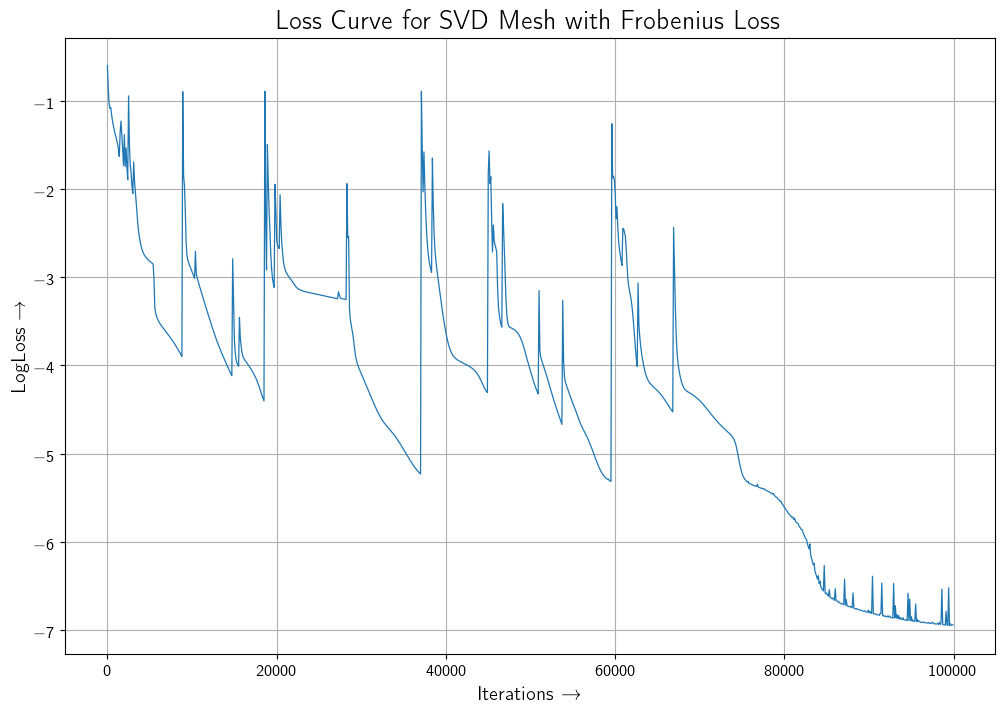

In [41]:
plt.figure(figsize=(12, 8))
plt.plot(np.arange(100000)[::100], np.log10(losses)[::100], lw=0.9)
plt.xlabel(r'Iterations $\rightarrow$', fontsize=15)
plt.ylabel(r'LogLoss $\rightarrow$', fontsize=15)
plt.title(f'Loss Curve for SVD Mesh with Frobenius Loss', fontsize=20)
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12) 
plt.grid()
plt.show()

In [36]:
plot_loss_curve(np.arange(100000)[::100], losses[::100], 'SVD mesh with Frobenius Loss')

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

<Figure size 1200x800 with 0 Axes>

### Results

In [ ]:
# peD = np.load('phase_arrays/phase_errors_D_act1.npy', allow_pickle=True)
# peU = np.load('phase_arrays/phase_errors_U_act1.npy', allow_pickle=True)
# peV = np.load('phase_arrays/phase_errors_V_act1.npy', allow_pickle=True)
# peDe = np.load('phase_arrays/phase_errors_D_est1.npy', allow_pickle=True)
# peUe = np.load('phase_arrays/phase_errors_U_est1.npy', allow_pickle=True)
# peVe = np.load('phase_arrays/phase_errors_V_est1.npy', allow_pickle=True)

In [15]:
# target = SVD(6, mesh_dict = {"name" : "rm"})
# est = SVD(6, mesh_dict = {"name" : "rm"})

In [16]:
# PhaseInitializer(target.u, *peU)
# PhaseInitializer(target.v, *peV)
# PhaseInitializer(est.u, *peUe)
# PhaseInitializer(est.v, *peVe)
# target.diag.sigma.assign(peD)
# est.diag.sigma.assign(peDe)

<tf.Variable 'UnreadVariable' shape=(6,) dtype=float32, numpy=
array([0.31522736, 0.03015517, 1.106709  , 1.6485816 , 1.8082435 ,
       0.57928264], dtype=float32)>

In [29]:
# A.diag.sigma, layer.diag.sigma

(<tf.Variable 'sigma:0' shape=(6,) dtype=float32, numpy=
 array([1.3892137 , 1.1521792 , 0.59221935, 0.51756096, 0.4609339 ,
        0.08069906], dtype=float32)>,
 <tf.Variable 'sigma:0' shape=(6,) dtype=float32, numpy=
 array([0.46096444, 0.51774055, 0.08055943, 1.389198  , 1.1524489 ,
        0.5922907 ], dtype=float32)>)

In [59]:
print_layer_loss(A, best_layer, best_loss)

Loss = 1.12276304e-07 

Target Matrix A: 
 [[ 0.0063-1.622e-01j -0.0224+6.500e-03j -0.1267-1.630e-02j
  -0.0382+1.900e-03j -0.0322+1.334e-01j  0.0287+1.868e-01j]
 [-0.0522-2.190e-02j  0.0287-1.173e-01j  0.1109+1.577e-01j
   0.0151-3.000e-04j  0.1105-5.320e-02j  0.2493-2.519e-01j]
 [ 0.0945+3.210e-02j -0.0613-3.100e-03j -0.2332+8.000e-03j
  -0.0097+2.770e-02j -0.1079+1.109e-01j -0.1371+1.134e-01j]
 [-0.1013+1.930e-02j  0.0073-7.990e-02j  0.0972+1.129e-01j
   0.0197-1.971e-01j  0.1713+4.870e-02j  0.2197-9.710e-02j]
 [ 0.0772-5.430e-02j  0.0537+7.730e-02j -0.2246-4.460e-02j
   0.2628-2.582e-01j  0.1042-4.662e-01j -0.1881+1.267e-01j]
 [ 0.2727+1.778e-01j -0.0403-7.690e-02j -0.0558-6.714e-01j
  -0.0856+2.063e-01j -0.2319-3.032e-01j -1.2176-3.060e-02j]] 

Estimated Matrix: 
 [[ 0.0065-1.625e-01j -0.0225+6.600e-03j -0.1266-1.630e-02j
  -0.0386+1.800e-03j -0.0318+1.333e-01j  0.0287+1.870e-01j]
 [-0.0522-2.150e-02j  0.0285-1.172e-01j  0.1107+1.578e-01j
   0.015 -6.000e-04j  0.1106-5.310e-02j  0

In [60]:
print_layer_loss(A, layer, losses[-1])

Loss = 1.12293414e-07 

Target Matrix A: 
 [[ 0.0063-1.622e-01j -0.0224+6.500e-03j -0.1267-1.630e-02j
  -0.0382+1.900e-03j -0.0322+1.334e-01j  0.0287+1.868e-01j]
 [-0.0522-2.190e-02j  0.0287-1.173e-01j  0.1109+1.577e-01j
   0.0151-3.000e-04j  0.1105-5.320e-02j  0.2493-2.519e-01j]
 [ 0.0945+3.210e-02j -0.0613-3.100e-03j -0.2332+8.000e-03j
  -0.0097+2.770e-02j -0.1079+1.109e-01j -0.1371+1.134e-01j]
 [-0.1013+1.930e-02j  0.0073-7.990e-02j  0.0972+1.129e-01j
   0.0197-1.971e-01j  0.1713+4.870e-02j  0.2197-9.710e-02j]
 [ 0.0772-5.430e-02j  0.0537+7.730e-02j -0.2246-4.460e-02j
   0.2628-2.582e-01j  0.1042-4.662e-01j -0.1881+1.267e-01j]
 [ 0.2727+1.778e-01j -0.0403-7.690e-02j -0.0558-6.714e-01j
  -0.0856+2.063e-01j -0.2319-3.032e-01j -1.2176-3.060e-02j]] 

Estimated Matrix: 
 [[ 0.0065-1.625e-01j -0.0225+6.600e-03j -0.1266-1.630e-02j
  -0.0386+1.800e-03j -0.0318+1.333e-01j  0.0287+1.870e-01j]
 [-0.0522-2.150e-02j  0.0285-1.172e-01j  0.1107+1.578e-01j
   0.015 -6.000e-04j  0.1106-5.310e-02j  0

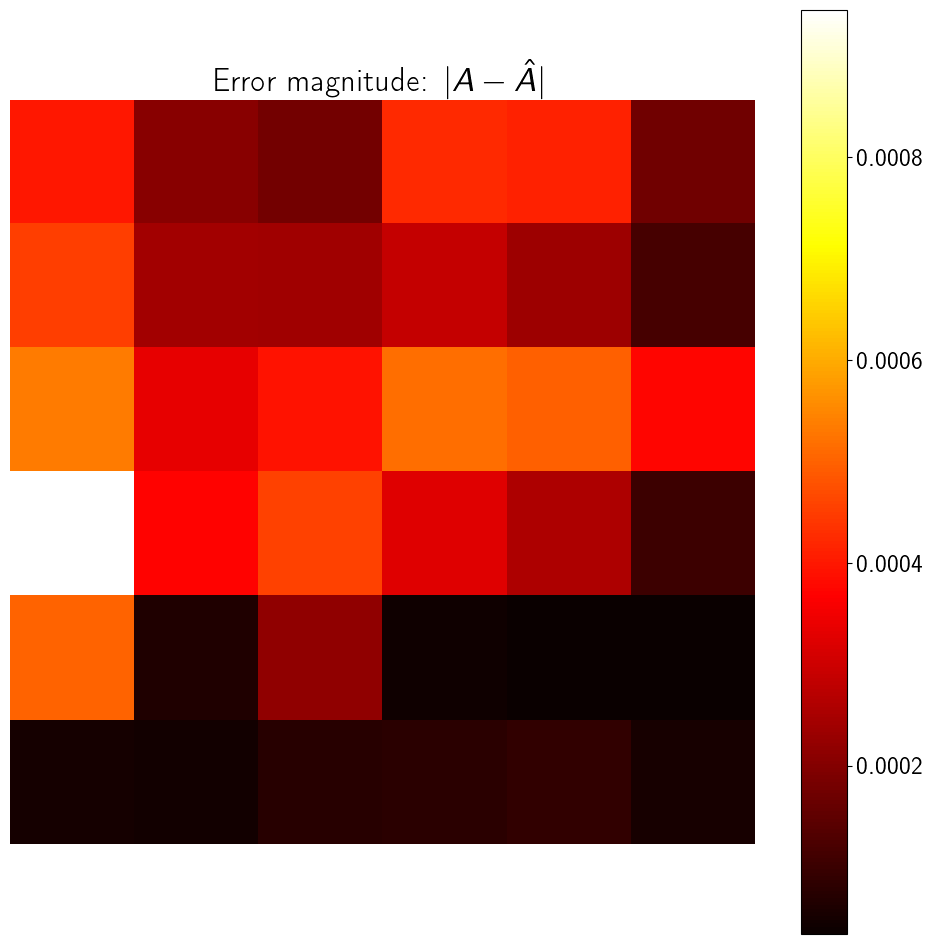

In [61]:
plot_error(A, best_layer)

In [62]:
compute_phase_deviation_permuted(A, best_layer)

For block U:
Actual theta errors: 
 [[0.0482011  0.39850101 0.37775758]
 [0.73760188 0.44874457 3.14159265]
 [0.78892416 0.43352109 0.34998542]
 [0.55017817 0.33087966 3.14159265]
 [0.04743808 0.19281295 0.45975032]
 [0.10616418 0.53208619 3.14159265]] 

Estimated theta errors: 
 [[0.03844592 0.57997335 0.37777096]
 [0.80480902 0.29283674 0.        ]
 [0.86203578 0.48113875 0.2793678 ]
 [0.60150374 0.37301573 0.        ]
 [0.11890197 0.22837821 0.23929414]
 [0.10599874 0.22270138 0.        ]] 

Max theta error:  0.3093848120803348
Min theta error:  1.3382718660082116e-05
Mean theta error:  0.08907999984385244
Count of greater than 3 degree theta error:  8 

Actual phi errors: 
 [[0.74616671 0.05677255 0.41366628]
 [0.88736832 0.37579894 3.14159265]
 [0.14200011 0.00927933 0.12145813]
 [0.79125792 0.71335423 3.14159265]
 [0.11900608 1.31655025 0.49924645]
 [0.41541433 0.39683104 3.14159265]] 

Estimated phi errors: 
 [[0.48345538 1.2371753  0.47117514]
 [0.56796167 5.96404462 0.        

In [48]:
d = A.diag.sigma.numpy()
asig = np.arccos(d / np.linalg.norm(d)) 

In [53]:
ed = sorted(best_layer.diag.sigma.numpy(), reverse=True)
esig = np.arccos(ed / np.linalg.norm(ed)) 

In [54]:
asig, esig

(array([0.42136383, 1.2013687 , 1.4603467 , 1.4620564 , 1.4855642 ,
        1.4950205 ], dtype=float32),
 array([0.42136413, 1.2013667 , 1.460563  , 1.4618484 , 1.4855609 ,
        1.495016  ], dtype=float32))

In [53]:
compute_phase_deviation_permuted(A, layer)

For block U:
Actual theta errors: 
 [[0.34908292 0.19856988 0.06871831]
 [0.08796877 0.48923978 3.14159265]
 [0.30252486 0.39614379 1.58757365]
 [0.02789312 0.97388524 3.14159265]
 [0.55829972 0.40814644 0.36871335]
 [0.50546306 0.24523672 3.14159265]] 

Estimated theta errors: 
 [[0.34764487 0.19928569 0.06936143]
 [0.08738299 0.48939076 0.        ]
 [0.30321927 0.39586987 1.58828095]
 [0.0281093  0.97353661 0.        ]
 [0.55828934 0.40829486 0.37096628]
 [0.50328835 0.24030741 0.        ]] 

Max theta error:  0.0049293112197697775
Min theta error:  1.0376715998572372e-05
Mean theta error:  0.0010193283094010314 

Actual phi errors: 
 [[0.65374911 0.43059993 0.87842005]
 [1.03676891 0.35390854 3.14159265]
 [0.03148341 0.1205093  0.02213309]
 [0.08697004 0.66713834 3.14159265]
 [0.37112641 0.38716829 0.52211779]
 [1.15521038 0.41545722 3.14159265]] 

Estimated phi errors: 
 [[1.37256897 0.43552925 0.86789051]
 [1.75465145 0.36025261 0.        ]
 [5.03351488 0.83484697 0.02718242]
 [5.

## Simulation 2

In [76]:
A2 = SVD(6, mesh_dict = {"name" : "rm"})

phasesU2 = NormalPhaseInitializer(A2.u, 0.1)       # Phases Errors in U
phasesVt2 = NormalPhaseInitializer(A2.v, 0.1)      # Phases Errors in Vt

In [77]:
# g = np.zeros((1, 6))
# g_ = tf.convert_to_tensor(g, dtype=tf.float32)
# A.u.gamma.assign(g_)

In [78]:
target_matrix2 = A2.matrix
# Instantiate an optimizer
optimizer = Adam(learning_rate=0.002)
# Instantiate a loss function
loss_fn = complex_mse
# Instantiate the ideal mesh
layer2 = SVD(6, mesh_dict={"name" : "rm"})
layer2.diag.sigma.assign(A2.diag.sigma.numpy())
# Preparing the training data
x_train, y_train = tf.eye(layer2.units, dtype=TF_COMPLEX),\
                               tf.convert_to_tensor(target_matrix2, dtype=TF_COMPLEX)

### Training

In [53]:
best_layer2, best_loss2, losses2 = train_SVD_layer_UV(layer2, x_train, y_train, loss_fn, optimizer, 100000)

2024-06-14 22:56:38,631 - tensorflow - WARNING - 5 out of the last 100008 calls to <function Diagonal.transform at 0x000002785F53C040> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


1000 iterations completed. Best Loss = 0.007459881249815226, Current Loss = 0.04098568856716156
2000 iterations completed. Best Loss = 0.002453581662848592, Current Loss = 0.025176316499710083
3000 iterations completed. Best Loss = 0.0012197733158245683, Current Loss = 0.0031569572165608406
4000 iterations completed. Best Loss = 0.0006752721965312958, Current Loss = 0.001080059097148478
5000 iterations completed. Best Loss = 0.00011324944352963939, Current Loss = 0.00011324944352963939
6000 iterations completed. Best Loss = 5.8764639106811956e-05, Current Loss = 5.8764639106811956e-05
7000 iterations completed. Best Loss = 2.3611661163158715e-05, Current Loss = 2.3611661163158715e-05
8000 iterations completed. Best Loss = 1.1037741387553979e-05, Current Loss = 1.1037741387553979e-05
9000 iterations completed. Best Loss = 8.855790838424582e-06, Current Loss = 8.855790838424582e-06
10000 iterations completed. Best Loss = 8.001064088603016e-06, Current Loss = 8.2824308265117e-06
11000 ite

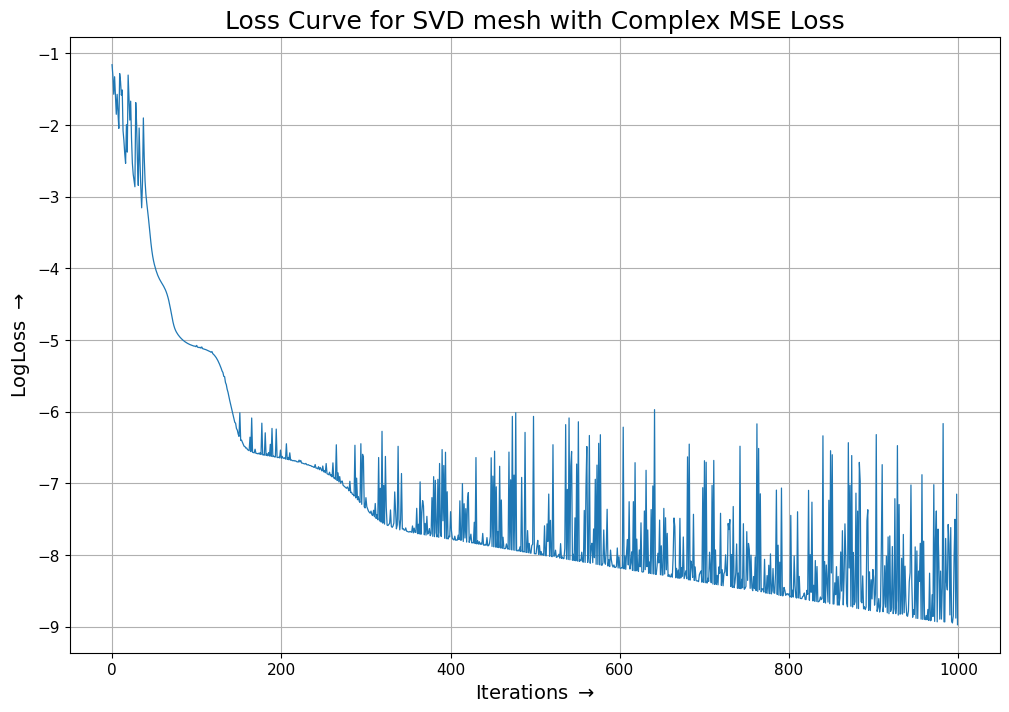

In [55]:
plot_loss_curve(1000, losses2[::100], 'SVD mesh with Complex MSE Loss')

### Results

In [56]:
print_layer_loss(A2, best_layer2, best_loss2)

Loss = 1.0463863e-09 

Target Matrix A: 
 [[-0.0057-0.0241j  0.0212+0.0243j -0.0035+0.028j  -0.1818+0.2083j
   0.0342-0.0964j -0.004 -0.023j ]
 [ 0.0055-0.0044j -0.0363-0.0225j  0.0043-0.0348j  0.0731-0.1505j
   0.0054-0.0743j -0.077 -0.0404j]
 [ 0.0689-0.0458j -0.1324-0.1061j -0.1596+0.1195j  0.0545-0.0051j
  -0.1357+0.2474j  0.0493+0.1899j]
 [ 0.0747+0.0097j  0.0093-0.0536j  0.0724+0.0469j -0.364 +0.0948j
  -0.1422-0.0538j  0.1493-0.2193j]
 [-0.0364-0.0189j  0.0452-0.0747j  0.2303+0.1412j  0.1423-0.0678j
  -0.5976-0.0102j -0.0427+0.0107j]
 [-0.1476-0.0798j  0.0337-0.0331j -0.0932+0.0714j  0.0922+0.1228j
  -0.5866+0.3177j -0.3872+0.8182j]] 

Estimated Matrix: 
 [[-0.0057-0.0241j  0.0211+0.0244j -0.0035+0.028j  -0.1818+0.2084j
   0.0342-0.0965j -0.0039-0.023j ]
 [ 0.0055-0.0044j -0.0363-0.0225j  0.0044-0.0348j  0.0731-0.1505j
   0.0055-0.0743j -0.0771-0.0403j]
 [ 0.0689-0.0458j -0.1324-0.106j  -0.1596+0.1195j  0.0545-0.0051j
  -0.1357+0.2474j  0.0493+0.1899j]
 [ 0.0747+0.0097j  0.0094-

In [37]:
print_layer_loss(A2, layer2, losses2[-1])

Loss = 0.004168438 

Target Matrix A: 
 [[-0.0326-0.006j   0.0464-0.0101j -0.085 +0.074j  -0.123 +0.0342j
  -0.0498-0.1373j  0.0117+0.02j  ]
 [ 0.005 +0.0552j -0.0273+0.0339j  0.0421-0.049j   0.0091+0.0344j
   0.0393-0.043j   0.0095-0.1442j]
 [ 0.0171-0.0098j  0.0007+0.0059j -0.0561+0.0158j -0.0074-0.0283j
  -0.0297-0.0269j -0.0687+0.0343j]
 [-0.0215+0.1152j  0.0676+0.1057j -0.1682-0.1333j -0.4015-0.0951j
   0.0743+0.0031j  0.0608+0.0064j]
 [ 0.2749+0.0713j -0.0091+0.0317j  0.0202-0.2073j -0.0218+0.1499j
   0.0091+0.4569j -0.0699+0.0059j]
 [ 0.1168-0.0983j  0.051 -0.0069j -0.1693-0.02j    0.0597-0.0649j
  -0.2233-0.0657j -0.4075+0.273j ]] 

Estimated Matrix: 
 [[-0.0323-0.006j   0.0463-0.0096j -0.0857+0.0742j -0.1226+0.034j
  -0.0503-0.1373j  0.0115+0.0199j]
 [ 0.0057+0.0548j -0.0274+0.0343j  0.0422-0.049j   0.0092+0.0344j
   0.0399-0.0433j  0.0097-0.144j ]
 [ 0.0169-0.0103j  0.0005+0.0055j -0.0557+0.0156j -0.0077-0.0282j
  -0.03  -0.0274j -0.0689+0.0343j]
 [-0.0214+0.1151j  0.0677+0.1

In [57]:
compute_phase_deviation_permuted(A2, best_layer2)

For block U:
Actual theta errors: 
 [[0.68393743 0.13655129 0.74103105]
 [1.16788328 0.57337213 3.14159265]
 [0.32969171 0.02349583 0.13040805]
 [0.23152705 0.72467673 3.14159265]
 [0.2700038  0.07733653 0.61703038]
 [0.96653026 0.07392305 3.14159265]] 

Estimated theta errors: 
 [[0.68219963 0.13669374 0.74105239]
 [1.1680126  0.57337801 0.        ]
 [0.32902026 0.02346847 0.13048261]
 [0.23152781 0.72462851 0.        ]
 [0.26999267 0.07754207 0.61695643]
 [0.96652592 0.07572415 0.        ]] 

Max theta error:  0.001801099182095825
Min theta error:  7.648029418938496e-07
Mean theta error:  0.0003303469131000112 

Actual phi errors: 
 [[0.30440977 0.33030319 0.23585351]
 [0.08844741 0.64295071 3.14159265]
 [0.24633925 0.2244443  0.21245354]
 [0.10884225 0.1976584  3.14159265]
 [0.3174198  0.29108915 0.66917515]
 [0.57423753 0.08337334 3.14159265]] 

Estimated phi errors: 
 [[2.6114899  0.32944394 0.23510103]
 [2.43679205 0.71248787 0.        ]
 [6.21183008 2.4792866  0.21190233]
 [6.09

In [41]:
layer2.u.theta

<tf.Variable 'theta:0' shape=(6, 3) dtype=float32, numpy=
array([[0.34826314, 0.10897054, 0.08371385],
       [0.67263573, 0.34139702, 0.        ],
       [0.10063252, 0.22990102, 0.09781087],
       [0.57000464, 0.5042941 , 0.        ],
       [0.3942586 , 0.03713821, 0.22153163],
       [0.05834452, 1.673246  , 0.        ]], dtype=float32)>

## Simulation 3

In [93]:
A3 = SVD(6, mesh_dict = {"name" : "rm"})

phasesU3 = NormalPhaseInitializer(A3.u, 0.1)       # Phases Errors in U
phasesVt3 = NormalPhaseInitializer(A3.v, 0.1)       # Phases Errors in Vt

In [94]:
target_matrix3 = A3.matrix
# Instantiate an optimizer
optimizer = Adam(learning_rate=0.005)
# Instantiate a loss function
loss_fn = frobenius_loss
# Instantiate the ideal mesh
layer3 = SVD(6, mesh_dict={"name" : "rm"})
layer3.diag.sigma.assign(A3.diag.sigma.numpy())
# layer.u.gamma.assign(g_)
# Preparing the training data
x_train3, y_train3 = tf.eye(layer3.units, dtype=TF_COMPLEX),\
                               tf.convert_to_tensor(target_matrix3, dtype=TF_COMPLEX)

In [95]:
best_layer3, best_loss3, losses3 = train_SVD_layer_UV(layer3, x_train3, y_train3, loss_fn, optimizer, 100000)

  0%|          | 0/100000 [00:00<?, ?it/s]

1000 iterations completed. Best Loss = 0.0035498812794685364, Current Loss = 0.01216901745647192
2000 iterations completed. Best Loss = 0.003319688141345978, Current Loss = 0.006680922117084265
3000 iterations completed. Best Loss = 0.0030147635843604803, Current Loss = 0.0030147635843604803
4000 iterations completed. Best Loss = 0.001360244699753821, Current Loss = 0.001360244699753821
5000 iterations completed. Best Loss = 0.0004010898992419243, Current Loss = 0.0004010898992419243
6000 iterations completed. Best Loss = 0.00016550962754990906, Current Loss = 0.00016550962754990906
7000 iterations completed. Best Loss = 0.00014741322956979275, Current Loss = 0.0031117729377001524
8000 iterations completed. Best Loss = 0.00014741322956979275, Current Loss = 0.0008744681254029274
9000 iterations completed. Best Loss = 0.00014741322956979275, Current Loss = 0.010049483738839626
10000 iterations completed. Best Loss = 0.00014741322956979275, Current Loss = 0.0013442517956718802
11000 iter

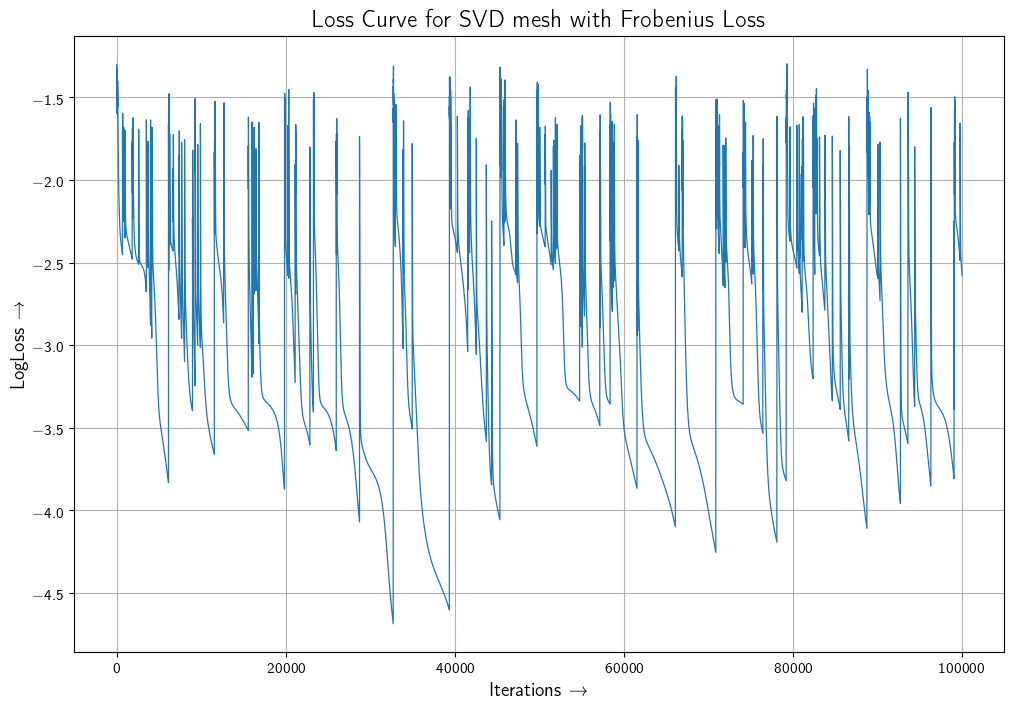

In [98]:
plot_loss_curve(100000, losses3, 'SVD mesh with Frobenius Loss')

In [100]:
print_layer_loss(A3, best_layer3, best_loss3)

Loss = 2.0628402e-05 

Target Matrix A: 
 [[-0.0957-0.1548j -0.1154+0.02j   -0.0776-0.0134j  0.0418+0.0724j
   0.0417-0.0428j  0.0139+0.014j ]
 [ 0.0989+0.007j  -0.0648+0.197j   0.0058+0.0359j  0.0808+0.1813j
   0.0291-0.0013j  0.0559-0.0093j]
 [ 0.1372-0.0711j  0.0527+0.086j   0.0014+0.2896j -0.0471-0.0794j
   0.0948+0.0883j -0.0812+0.1035j]
 [ 0.1158+0.0107j -0.1073-0.0213j  0.0282-0.0338j -0.0797-0.2981j
  -0.0684-0.0818j  0.1079+0.0276j]
 [-0.0297-0.01j   -0.193 +0.046j   0.2454+0.0122j  0.0987-0.023j
  -0.1698+0.2166j  0.0227-0.0882j]
 [ 0.0099-0.0287j  0.0202+0.0337j  0.0738-0.0102j -0.0314+0.0043j
  -0.1585-0.1368j -0.4173-0.0748j]] 

Estimated Matrix: 
 [[-0.096 -0.1516j -0.1175+0.0179j -0.0779-0.0137j  0.0412+0.0743j
   0.0385-0.0404j  0.0153+0.0144j]
 [ 0.0979+0.0098j -0.0692+0.1999j  0.0078+0.0369j  0.0858+0.1805j
   0.0251+0.0003j  0.0567-0.009j ]
 [ 0.0204+0.0024j -0.1375-0.0047j  0.2129+0.1056j  0.1585-0.0824j
  -0.1848+0.163j  -0.0761+0.1252j]
 [ 0.1065-0.0628j -0.019 -0

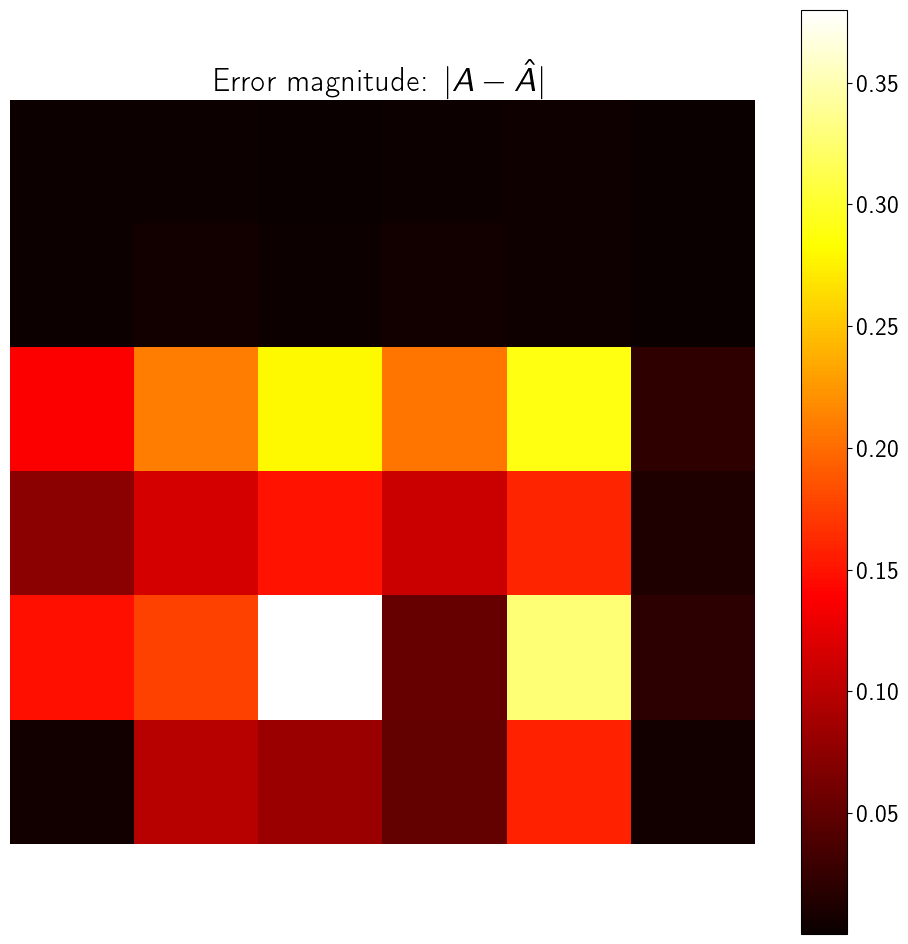

In [101]:
plot_error(A3, best_layer3)

In [105]:
print_layer_loss(A3, layer3, losses3[-1])

Loss = 0.0026363449 

Target Matrix A: 
 [[-0.0957-0.1548j -0.1154+0.02j   -0.0776-0.0134j  0.0418+0.0724j
   0.0417-0.0428j  0.0139+0.014j ]
 [ 0.0989+0.007j  -0.0648+0.197j   0.0058+0.0359j  0.0808+0.1813j
   0.0291-0.0013j  0.0559-0.0093j]
 [ 0.1372-0.0711j  0.0527+0.086j   0.0014+0.2896j -0.0471-0.0794j
   0.0948+0.0883j -0.0812+0.1035j]
 [ 0.1158+0.0107j -0.1073-0.0213j  0.0282-0.0338j -0.0797-0.2981j
  -0.0684-0.0818j  0.1079+0.0276j]
 [-0.0297-0.01j   -0.193 +0.046j   0.2454+0.0122j  0.0987-0.023j
  -0.1698+0.2166j  0.0227-0.0882j]
 [ 0.0099-0.0287j  0.0202+0.0337j  0.0738-0.0102j -0.0314+0.0043j
  -0.1585-0.1368j -0.4173-0.0748j]] 

Estimated Matrix: 
 [[-0.1474-0.2613j -0.2028+0.0277j -0.1113+0.0177j  0.0474+0.073j
   0.0488-0.0688j -0.022 +0.0347j]
 [ 0.1369+0.0118j -0.0804+0.2771j -0.0117+0.056j   0.0576+0.1335j
   0.046 -0.0332j  0.0621+0.015j ]
 [ 0.1899-0.1214j  0.0282+0.1296j -0.0167+0.2801j -0.0497-0.0682j
   0.0801+0.0574j -0.0475+0.1066j]
 [ 0.1267+0.0205j -0.1476+0.0

In [107]:
compute_phase_deviation_permuted(A3, best_layer3)

For block U:
Actual theta errors: 
 [[ 80.1720638   13.27775541   2.18702849]
 [ 19.97830161  29.3420692  180.        ]
 [ 65.48576372   6.75940749  37.75173279]
 [ 20.46954931  15.38073736 180.        ]
 [ 12.56507981   7.28723555  41.44912251]
 [ 37.66044731  26.17571815 180.        ]] 

Estimated theta errors: 
 [[ 65.37700421  55.79279826  25.65439624]
 [ 26.79695492  26.95400875   0.        ]
 [ 63.25172145  12.25806169 179.976837  ]
 [ 24.85284634  18.72045012   0.        ]
 [ 22.3955226   12.67890764  23.5369841 ]
 [ 47.9261579   36.1679347    0.        ]] 

Max theta error:  142.2251042155604
Min theta error:  2.2340422707013388
Mean theta error:  20.07047832315445 

Actual phi errors: 
 [[ 61.57702405   2.23712516  26.12760801]
 [ 13.64647464  21.62236401 180.        ]
 [ 96.01614241   6.28085883  60.18966919]
 [ 30.76324032   5.09395466 180.        ]
 [ 27.06058624  10.58355314  31.85234814]
 [ 27.21952815   9.254085   180.        ]] 

Estimated phi errors: 
 [[283.90011005 1

In [36]:
compute_phase_deviation_permuted(A, layer)

For block U:
Actual theta errors: 
 [[ 42.18540665  27.6259893   24.64768531]
 [ 59.46472657  51.83392654 180.        ]
 [ 44.45580593  13.65097829  80.10601587]
 [ 61.15253462   1.54069132 180.        ]
 [ 10.64522292  43.60656411   5.20053848]
 [  5.78456533  64.91329825 180.        ]] 

Estimated theta errors: 
 [[42.15502796 36.26460523 23.19953231]
 [59.63337786 54.91821508  0.        ]
 [47.9823562  11.5125079  80.70696971]
 [60.93112188  1.83155829  0.        ]
 [ 6.96001187 40.24717297  7.59214485]
 [ 3.13223756 65.30496687  0.        ]] 

Max theta error:  8.638615931139714
Min theta error:  0.03037869667894306
Mean theta error:  2.1752364412377325 

Actual phi errors: 
 [[5.07506824e+01 2.67199698e+01 2.99699343e+01]
 [3.22801775e+01 4.29024058e+01 1.80000000e+02]
 [4.53817337e+01 1.45009665e-01 4.05919030e+01]
 [2.32444742e+01 4.59349346e+01 1.80000000e+02]
 [6.42438236e+01 1.02674605e+01 6.05263446e+00]
 [4.44727790e+01 5.22524293e+01 1.80000000e+02]] 

Estimated phi errors

## Simulation 4

In [56]:
A4 = SVD(6, mesh_dict = {"name" : "rm"})

phasesU4 = NormalPhaseInitializer(A4.u, 0.1)       # Phases Errors in U
phasesVt4 = NormalPhaseInitializer(A4.v, 0.1)       # Phases Errors in Vt

In [57]:
target_matrix4 = A4.matrix
# Instantiate an optimizer
optimizer = Adam(learning_rate=0.002)
# Instantiate a loss function
loss_fn = frobenius_loss
# Instantiate the ideal mesh
layer4 = SVD(6, mesh_dict={"name" : "rm"})
layer4.diag.sigma.assign(A4.diag.sigma.numpy())
# Preparing the training data
x_train, y_train = tf.eye(layer4.units, dtype=TF_COMPLEX),\
                               tf.convert_to_tensor(target_matrix4, dtype=TF_COMPLEX)

In [58]:
best_layer4, best_loss4, losses4 = train_SVD_layer_UV(layer4, x_train, y_train, loss_fn, optimizer, 100000)

  0%|          | 0/100000 [00:00<?, ?it/s]

1000 iterations completed. Best Loss = 0.06592103838920593, Current Loss = 0.07613412290811539
2000 iterations completed. Best Loss = 0.05221821740269661, Current Loss = 0.05221821740269661
3000 iterations completed. Best Loss = 0.04175470396876335, Current Loss = 0.06182321533560753
4000 iterations completed. Best Loss = 0.04175470396876335, Current Loss = 0.05306398868560791
5000 iterations completed. Best Loss = 0.04175470396876335, Current Loss = 0.05560960993170738
6000 iterations completed. Best Loss = 0.04175470396876335, Current Loss = 0.09457457065582275
7000 iterations completed. Best Loss = 0.04175470396876335, Current Loss = 0.041901808232069016
8000 iterations completed. Best Loss = 0.03208128362894058, Current Loss = 0.038078512996435165
9000 iterations completed. Best Loss = 0.022181084379553795, Current Loss = 0.0764026865363121
10000 iterations completed. Best Loss = 0.022181084379553795, Current Loss = 0.04478420317173004
11000 iterations completed. Best Loss = 0.0221

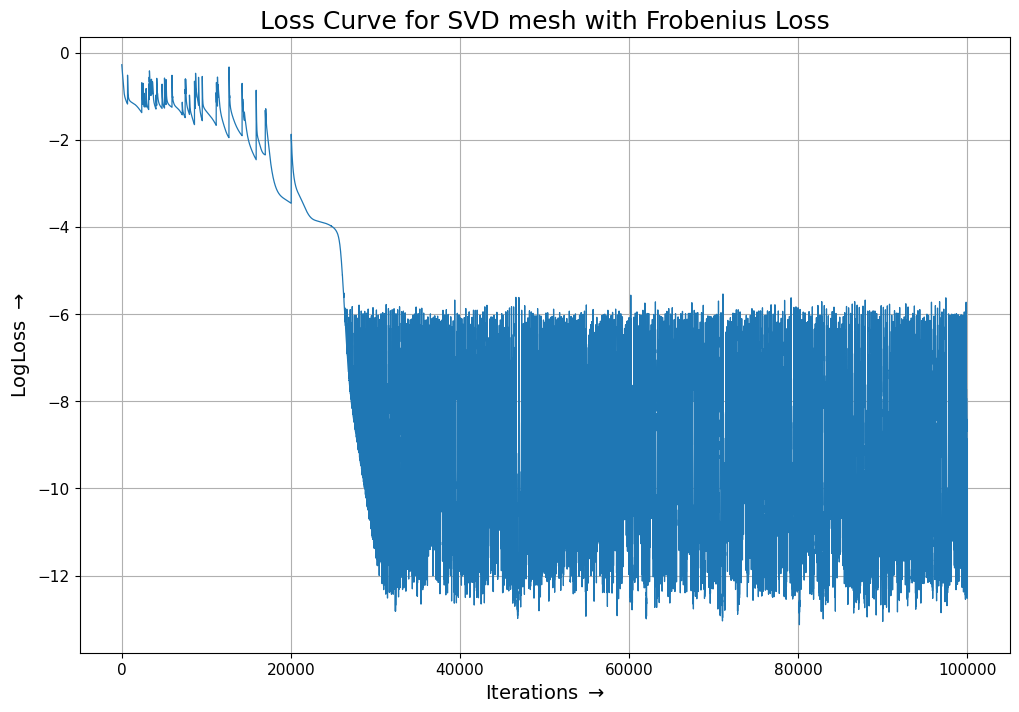

In [59]:
plot_loss_curve(100000, losses4, 'SVD mesh with Frobenius Loss')

In [60]:
print_layer_loss(A4, best_layer4, best_loss4)

Loss = 7.43595e-14 

Target Matrix A: 
 [[-0.5215+0.1526j  0.4205-0.2227j -0.4046-0.4869j -0.1187-0.3091j
   0.4797+0.271j  -0.7119+0.5117j]
 [ 0.6672-0.2207j -0.4091-0.1717j -0.4642+0.1639j  0.321 +0.358j
   0.2555+0.4167j  0.3755+0.0545j]
 [-0.5172+0.1136j -0.1987-0.0931j -0.1092+0.1001j  0.4136-0.1682j
  -0.2316+0.324j  -0.3167-0.2365j]
 [ 0.5203+0.5307j -0.3583-0.0443j -0.1223-0.2455j -0.1049-0.0799j
   0.1535-0.4997j  0.4212-0.2085j]
 [ 0.1437+0.4692j  0.8314+0.0254j -0.4598+0.3353j -0.1997-0.2656j
  -0.7254+0.3231j -0.1095+0.2616j]
 [ 0.4886-0.1041j  0.1094+0.0613j -0.1421+0.1014j  0.2116-0.1665j
  -0.3322+0.5397j -0.0153-0.4126j]] 

Estimated Matrix: 
 [[-0.5215+0.1526j  0.4205-0.2227j -0.4046-0.4869j -0.1187-0.3091j
   0.4797+0.271j  -0.7119+0.5117j]
 [ 0.6672-0.2207j -0.4091-0.1717j -0.4642+0.1639j  0.321 +0.358j
   0.2555+0.4168j  0.3755+0.0545j]
 [-0.5172+0.1136j -0.1987-0.0931j -0.1092+0.1001j  0.4136-0.1682j
  -0.2316+0.324j  -0.3167-0.2365j]
 [ 0.5203+0.5307j -0.3583-0.04

In [ ]:
print_layer_loss(A, layer, losses[-1])

Loss = 4.5690274e-07 

Target Matrix A: 
 [[-0.1131+0.0533j -0.0995-0.1098j  0.0204-0.1651j -0.1234+0.034j
  -0.0425+0.0461j  0.1361-0.0071j]
 [-0.2315-0.1017j  0.0277-0.2114j -0.0451+0.2592j -0.1464+0.17j
  -0.107 -0.052j   0.1472+0.1142j]
 [ 0.0876-0.0701j  0.1284-0.2879j -0.0454-0.2875j  0.2129+0.1559j
   0.0842+0.0805j -0.1835+0.0301j]
 [-0.1822-0.0191j  0.0344-0.0204j  0.2553-0.1591j -0.0355-0.3477j
   0.0209-0.0045j  0.1084+0.1304j]
 [-0.1191+0.0555j  0.0979-0.0324j -0.0793-0.0416j  0.1875-0.1065j
  -0.3449-0.3975j  0.0783-0.1163j]
 [ 0.3101-0.0934j -0.1381+0.0491j  0.1102-0.0616j -0.1075+0.0644j
  -0.2741-0.2262j -0.2851+0.0964j]] 

Estimated Matrix: 
 [[-0.1128+0.0534j -0.0996-0.1095j  0.0205-0.1648j -0.1228+0.0336j
  -0.043 +0.0461j  0.1361-0.0072j]
 [-0.2316-0.1019j  0.0271-0.2109j -0.0447+0.2607j -0.1472+0.1702j
  -0.107 -0.0519j  0.1471+0.1149j]
 [ 0.0881-0.07j    0.1287-0.2877j -0.0447-0.2885j  0.2138+0.1547j
   0.0843+0.0803j -0.184 +0.0301j]
 [-0.182 -0.0187j  0.0342-0.0

In [61]:
compute_phase_deviation_permuted(A4, best_layer4)

For block U:
Actual theta errors: 
 [[ 76.70527151  76.13893272 117.07355415]
 [ 42.85581021  58.09069059 180.        ]
 [115.14499559  84.03627064  49.68677119]
 [ 31.90941095  37.34263861 180.        ]
 [100.21683169  49.77414297  86.3025479 ]
 [ 28.2701598  148.89354768 180.        ]] 

Estimated theta errors: 
 [[ 76.70528625  76.13888376 117.07352295]
 [ 42.85581731  58.09071567   0.        ]
 [115.1451686   84.03627898  49.68666405]
 [ 31.90950192  37.34267594   0.        ]
 [100.2168143   49.77423737  86.30257708]
 [ 28.26999932 148.89348241   0.        ]] 

Max theta error:  0.0001730027962643854
Min theta error:  7.102824408974995e-06
Mean theta error:  6.0705827204473284e-05 

Actual phi errors: 
 [[226.20773739 306.93219956  46.10847265]
 [ 70.45810729 355.90091297 180.        ]
 [ 29.28380086 270.42847211  62.03108136]
 [ 61.52908295 274.7325568  180.        ]
 [320.73773308 315.63661996  30.00159568]
 [300.41155457 296.686506   180.        ]] 

Estimated phi errors: 
 [[19

In [63]:
at_U = np.radians([
    [76.70527151, 76.13893272, 117.07355415],
    [42.85581021, 58.09069059, 180.0],
    [115.14499559, 84.03627064, 49.68677119],
    [31.90941095, 37.34263861, 180.0],
    [100.21683169, 49.77414297, 86.3025479],
    [28.2701598, 148.89354768, 180.0]
])

et_U = np.radians([
    [76.70528625, 76.13888376, 117.07352295],
    [42.85581731, 58.09071567, 0.0],
    [115.1451686, 84.03627898, 49.68666405],
    [31.90950192, 37.34267594, 0.0],
    [100.2168143, 49.77423737, 86.30257708],
    [28.26999932, 148.89348241, 0.0]
])

ap_U = np.radians([
    [226.20773739, 306.93219956, 46.10847265],
    [70.45810729, 355.90091297, 180.0],
    [29.28380086, 270.42847211, 62.03108136],
    [61.52908295, 274.7325568, 180.0],
    [320.73773308, 315.63661996, 30.00159568],
    [300.41155457, 296.686506, 180.0]
])

ep_U = np.radians([
    [199.26130799, 306.93225872, 46.10841156],
    [43.51175823, 355.90090754, 0.0],
    [309.35942173, 243.48260384, 62.03115323],
    [341.60418244, 247.78609652, 0.0],
    [282.75354757, 235.71196875, 3.05526846],
    [222.48788876, 311.12030036, 0.0]
])

ag_U = np.radians([97.12704, 29.01015, 181.51497, 57.349354, 343.42712, 155.47151])
eg_U = np.radians([179.58512905, 111.46824503, 263.97302571, 139.80737899, 65.88537603, 237.92959565])

at_V = np.radians([
    [26.18782637, 139.65023902, 16.48702993],
    [54.23466631, 98.50818474, 180.0],
    [46.83176578, 55.92639489, 48.08452151],
    [50.21736761, 62.00589163, 180.0],
    [91.51157118, 54.84822562, 55.89325481],
    [37.16257775, 13.81696726, 180.0]
])

et_V = np.radians([
    [26.18776307, 139.65031056, 16.48708975],
    [54.23467204, 98.50824433, 0.0],
    [46.83172605, 55.92643815, 48.08448726],
    [50.21734844, 62.00590083, 0.0],
    [91.51157233, 54.84821051, 55.89327254],
    [37.16254833, 13.81693813, 0.0]
])

ap_V = np.radians([
    [90.88852815, 301.71450877, 172.31634272],
    [344.70505813, 54.6700977, 180.0],
    [217.12286179, 293.23100401, 301.65300975],
    [106.16356321, 212.89985145, 180.0],
    [350.59527666, 257.72858229, 262.93433391],
    [289.17895331, 19.55506553, 180.0]
])

ep_V = np.radians([
    [90.8884621, 301.7141242, 172.31626074],
    [344.70502275, 54.67007753, 0.0],
    [217.12288358, 293.23099965, 301.65298185],
    [106.16355982, 212.89984597, 0.0],
    [350.59527317, 257.7285806, 262.93436403],
    [289.1789541, 19.55503803, 0.0]
])

ag_V = np.radians([154.08226, 199.13402, 292.5249, 105.71049, 210.81079, 2.4818633])
eg_V = np.radians([216.4791286, 301.47065285, 316.93799313, 35.76500489, 155.29907427, 280.02388949])

asig = np.array([1.9777986, 1.685225, 0.99319035, 0.91212374, 0.480314, 0.05648351])
esig = np.array([1.97779858, 1.68522501, 0.99319035, 0.91212374, 0.48031399, 0.05648351])

A = SVD(6, mesh_dict={"name" : "rm"})
B = SVD(6, mesh_dict={"name" : "rm"})

PhaseInitializer(A.u, at_U, ap_U, ag_U)
PhaseInitializer(B.u, et_U, ep_U, eg_U)

PhaseInitializer(A.v, at_V, ap_V, ag_V)
PhaseInitializer(B.v, et_V, ep_V, eg_V)

A.diag.sigma.assign(asig)
B.diag.sigma.assign(esig)

<tf.Variable 'UnreadVariable' shape=(6,) dtype=float32, numpy=
array([1.9777986 , 1.685225  , 0.99319035, 0.91212374, 0.480314  ,
       0.05648351], dtype=float32)>

In [64]:
compute_phase_deviation_permuted(A, B)

For block U:
Actual theta errors: 
 [[1.33875954 1.32887506 2.04331899]
 [0.74797499 1.01387382 3.14159265]
 [2.00965929 1.46670961 0.86719775]
 [0.55692428 0.651752   3.14159265]
 [1.74911368 0.86872268 1.50626361]
 [0.49340737 2.59868264 3.14159265]] 

Estimated theta errors: 
 [[1.3387598  1.32887428 2.0433186 ]
 [0.74797513 1.01387428 0.        ]
 [2.00966245 1.46670972 0.86719593]
 [0.55692591 0.65175271 0.        ]
 [1.74911331 0.86872441 1.50626419]
 [0.49340458 2.59868147 0.        ]] 

Max theta error:  3.1592042066819204e-06
Min theta error:  1.0548256623721386e-07
Mean theta error:  1.0740910399801666e-06
Count of greater than 3 degree theta error:  0 

Actual phi errors: 
 [[3.94806981 5.35697746 0.80474466]
 [1.22972596 6.21164274 3.14159265]
 [0.51109874 4.71986723 1.08264661]
 [1.07388508 4.79498768 3.14159265]
 [5.59792948 5.50889826 0.52362663]
 [5.24317074 5.17815638 3.14159265]] 

Estimated phi errors: 
 [[3.47776577 5.35697848 0.80474355]
 [0.75942319 6.21164258 0. 

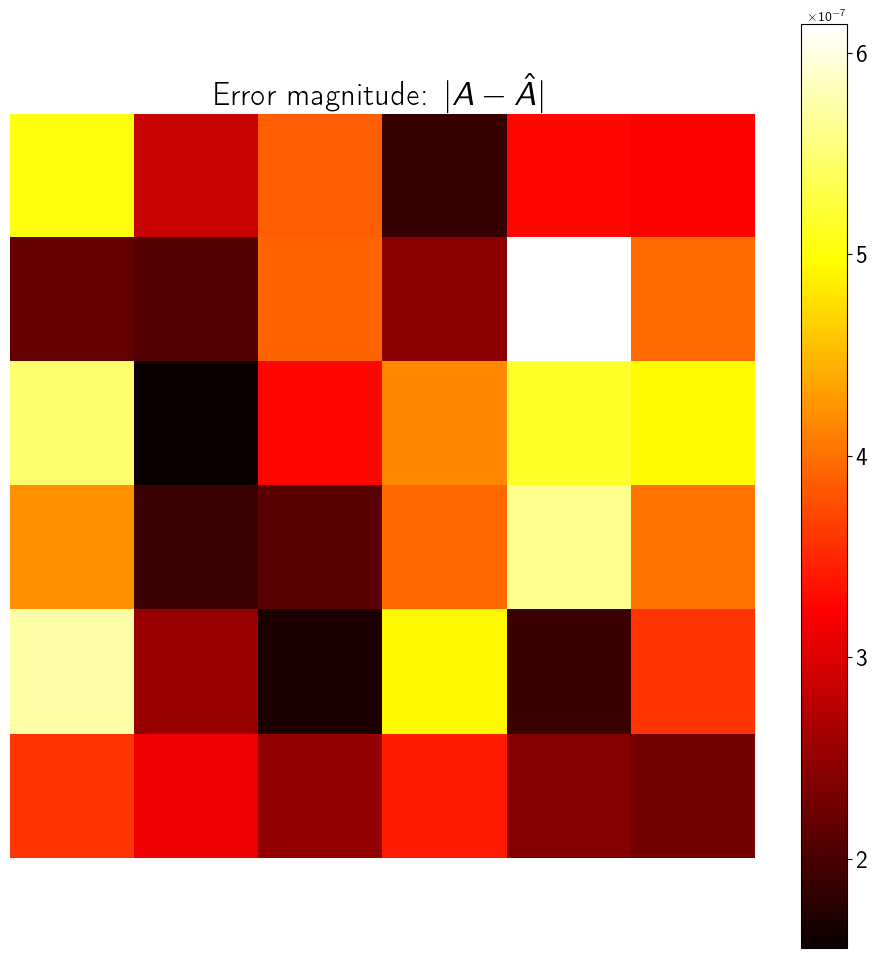

In [65]:
plot_error(A, B)

In [ ]:
compute_phase_deviation_permuted(A, layer)

For block U:
Actual theta errors: 
 [[ 42.18540665  27.6259893   24.64768531]
 [ 59.46472657  51.83392654 180.        ]
 [ 44.45580593  13.65097829  80.10601587]
 [ 61.15253462   1.54069132 180.        ]
 [ 10.64522292  43.60656411   5.20053848]
 [  5.78456533  64.91329825 180.        ]] 

Estimated theta errors: 
 [[42.15502796 36.26460523 23.19953231]
 [59.63337786 54.91821508  0.        ]
 [47.9823562  11.5125079  80.70696971]
 [60.93112188  1.83155829  0.        ]
 [ 6.96001187 40.24717297  7.59214485]
 [ 3.13223756 65.30496687  0.        ]] 

Max theta error:  8.638615931139714
Min theta error:  0.03037869667894306
Mean theta error:  2.1752364412377325 

Actual phi errors: 
 [[5.07506824e+01 2.67199698e+01 2.99699343e+01]
 [3.22801775e+01 4.29024058e+01 1.80000000e+02]
 [4.53817337e+01 1.45009665e-01 4.05919030e+01]
 [2.32444742e+01 4.59349346e+01 1.80000000e+02]
 [6.42438236e+01 1.02674605e+01 6.05263446e+00]
 [4.44727790e+01 5.22524293e+01 1.80000000e+02]] 

Estimated phi errors

## Smulaton 5

In [80]:
A5 = SVD(6, mesh_dict = {"name" : "rm"})

phasesU5 = NormalPhaseInitializer(A5.u, 0.1)       # Phases Errors in U
phasesVt5 = NormalPhaseInitializer(A5.v, 0.1)       # Phases Errors in Vt

In [85]:
target_matrix5 = A5.matrix
# Instantiate an optimizer
optimizer = Adam(learning_rate=0.002)
# Instantiate a loss function
loss_fn = frobenius_loss
# Instantiate the ideal mesh
layer5 = SVD(6, mesh_dict={"name" : "rm"})
layer5.diag.sigma.assign(A5.diag.sigma.numpy())
# Preparing the training data
x_train5, y_train5 = tf.eye(layer5.units, dtype=TF_COMPLEX),\
                               tf.convert_to_tensor(target_matrix5, dtype=TF_COMPLEX)

In [86]:
best_layer5, best_loss5, losses5 = train_SVD_layer_UV(layer5, x_train5, y_train5, loss_fn, optimizer, 100000)

  0%|          | 0/100000 [00:00<?, ?it/s]

1000 iterations completed. Best Loss = 0.17372262477874756, Current Loss = 0.23674647510051727
2000 iterations completed. Best Loss = 0.11499150842428207, Current Loss = 0.12511973083019257
3000 iterations completed. Best Loss = 0.04927526041865349, Current Loss = 0.15159200131893158
4000 iterations completed. Best Loss = 0.02427448146045208, Current Loss = 0.15273253619670868
5000 iterations completed. Best Loss = 0.02427448146045208, Current Loss = 0.17472602427005768
6000 iterations completed. Best Loss = 0.02427448146045208, Current Loss = 0.0533079169690609
7000 iterations completed. Best Loss = 0.013082645833492279, Current Loss = 0.013082645833492279
8000 iterations completed. Best Loss = 0.01034518051892519, Current Loss = 0.20955049991607666
9000 iterations completed. Best Loss = 0.007399506401270628, Current Loss = 0.272223562002182
10000 iterations completed. Best Loss = 0.007399506401270628, Current Loss = 0.034557051956653595
11000 iterations completed. Best Loss = 0.00739

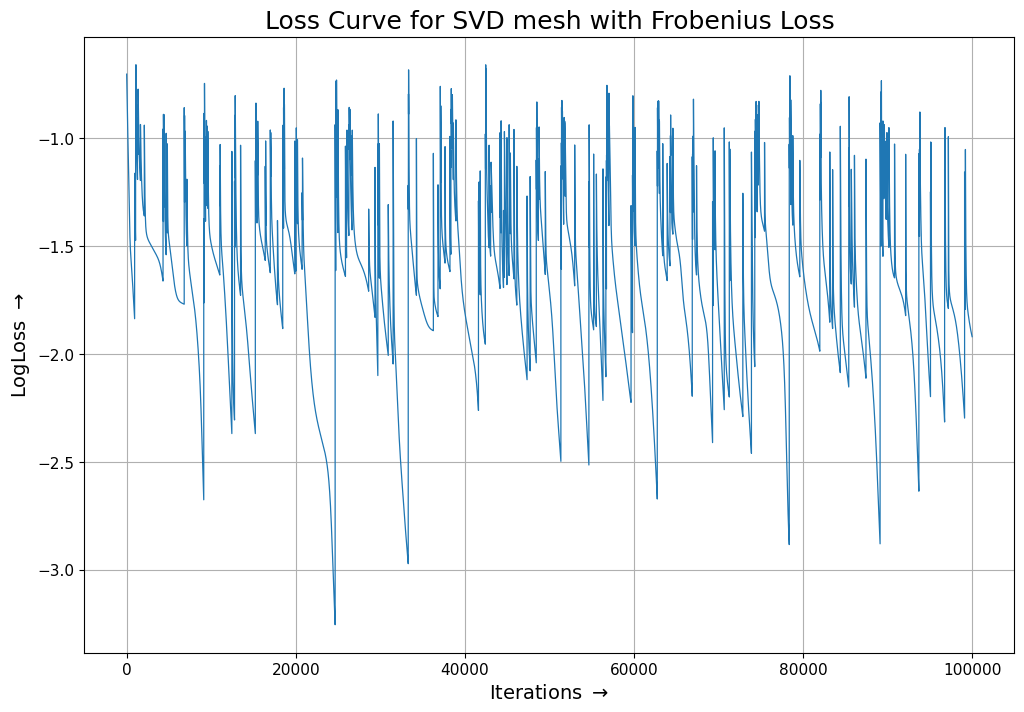

In [99]:
plot_loss_curve(100000, losses5, 'SVD mesh with Frobenius Loss')

In [ ]:
print_layer_loss(A4, best_layer4, best_loss4)

Loss = 7.43595e-14 

Target Matrix A: 
 [[-0.5215+0.1526j  0.4205-0.2227j -0.4046-0.4869j -0.1187-0.3091j
   0.4797+0.271j  -0.7119+0.5117j]
 [ 0.6672-0.2207j -0.4091-0.1717j -0.4642+0.1639j  0.321 +0.358j
   0.2555+0.4167j  0.3755+0.0545j]
 [-0.5172+0.1136j -0.1987-0.0931j -0.1092+0.1001j  0.4136-0.1682j
  -0.2316+0.324j  -0.3167-0.2365j]
 [ 0.5203+0.5307j -0.3583-0.0443j -0.1223-0.2455j -0.1049-0.0799j
   0.1535-0.4997j  0.4212-0.2085j]
 [ 0.1437+0.4692j  0.8314+0.0254j -0.4598+0.3353j -0.1997-0.2656j
  -0.7254+0.3231j -0.1095+0.2616j]
 [ 0.4886-0.1041j  0.1094+0.0613j -0.1421+0.1014j  0.2116-0.1665j
  -0.3322+0.5397j -0.0153-0.4126j]] 

Estimated Matrix: 
 [[-0.5215+0.1526j  0.4205-0.2227j -0.4046-0.4869j -0.1187-0.3091j
   0.4797+0.271j  -0.7119+0.5117j]
 [ 0.6672-0.2207j -0.4091-0.1717j -0.4642+0.1639j  0.321 +0.358j
   0.2555+0.4168j  0.3755+0.0545j]
 [-0.5172+0.1136j -0.1987-0.0931j -0.1092+0.1001j  0.4136-0.1682j
  -0.2316+0.324j  -0.3167-0.2365j]
 [ 0.5203+0.5307j -0.3583-0.04

In [ ]:
print_layer_loss(A, layer, losses[-1])

Loss = 4.5690274e-07 

Target Matrix A: 
 [[-0.1131+0.0533j -0.0995-0.1098j  0.0204-0.1651j -0.1234+0.034j
  -0.0425+0.0461j  0.1361-0.0071j]
 [-0.2315-0.1017j  0.0277-0.2114j -0.0451+0.2592j -0.1464+0.17j
  -0.107 -0.052j   0.1472+0.1142j]
 [ 0.0876-0.0701j  0.1284-0.2879j -0.0454-0.2875j  0.2129+0.1559j
   0.0842+0.0805j -0.1835+0.0301j]
 [-0.1822-0.0191j  0.0344-0.0204j  0.2553-0.1591j -0.0355-0.3477j
   0.0209-0.0045j  0.1084+0.1304j]
 [-0.1191+0.0555j  0.0979-0.0324j -0.0793-0.0416j  0.1875-0.1065j
  -0.3449-0.3975j  0.0783-0.1163j]
 [ 0.3101-0.0934j -0.1381+0.0491j  0.1102-0.0616j -0.1075+0.0644j
  -0.2741-0.2262j -0.2851+0.0964j]] 

Estimated Matrix: 
 [[-0.1128+0.0534j -0.0996-0.1095j  0.0205-0.1648j -0.1228+0.0336j
  -0.043 +0.0461j  0.1361-0.0072j]
 [-0.2316-0.1019j  0.0271-0.2109j -0.0447+0.2607j -0.1472+0.1702j
  -0.107 -0.0519j  0.1471+0.1149j]
 [ 0.0881-0.07j    0.1287-0.2877j -0.0447-0.2885j  0.2138+0.1547j
   0.0843+0.0803j -0.184 +0.0301j]
 [-0.182 -0.0187j  0.0342-0.0

In [ ]:
compute_phase_deviation_permuted(A4, best_layer4)

For block U:
Actual theta errors: 
 [[ 76.70527151  76.13893272 117.07355415]
 [ 42.85581021  58.09069059 180.        ]
 [115.14499559  84.03627064  49.68677119]
 [ 31.90941095  37.34263861 180.        ]
 [100.21683169  49.77414297  86.3025479 ]
 [ 28.2701598  148.89354768 180.        ]] 

Estimated theta errors: 
 [[ 76.70528625  76.13888376 117.07352295]
 [ 42.85581731  58.09071567   0.        ]
 [115.1451686   84.03627898  49.68666405]
 [ 31.90950192  37.34267594   0.        ]
 [100.2168143   49.77423737  86.30257708]
 [ 28.26999932 148.89348241   0.        ]] 

Max theta error:  0.0001730027962643854
Min theta error:  7.102824408974995e-06
Mean theta error:  6.0705827204473284e-05 

Actual phi errors: 
 [[226.20773739 306.93219956  46.10847265]
 [ 70.45810729 355.90091297 180.        ]
 [ 29.28380086 270.42847211  62.03108136]
 [ 61.52908295 274.7325568  180.        ]
 [320.73773308 315.63661996  30.00159568]
 [300.41155457 296.686506   180.        ]] 

Estimated phi errors: 
 [[19

## Simulation 6

In [25]:
U = RM(6)
NormalPhaseInitializer(U, 0.1)

(array([[0.20366455, 0.22302429, 0.137926  ],
        [0.84997935, 0.76635064, 0.        ],
        [0.21941559, 0.81438173, 0.55927845],
        [0.17503599, 0.61932682, 0.        ],
        [0.03654414, 0.57590832, 0.39061988],
        [1.19117158, 0.14109628, 0.        ]]),
 array([[0.32546704, 0.76857727, 0.3873721 ],
        [0.06772025, 0.95889969, 0.        ],
        [0.09106075, 0.55135171, 0.78705802],
        [0.16066356, 0.25357764, 0.        ],
        [0.53328129, 0.4524735 , 0.16383841],
        [0.33877467, 1.03490981, 0.        ]]),
 array([[1.30490561, 0.1775281 , 0.54354723, 0.15924094, 0.02369811,
         0.36460243]]))

In [26]:
target_matrix6 = U.matrix
# Instantiate an optimizer
optimizer = Adam(learning_rate=0.002)
# Instantiate a loss function
loss_fn = frobenius_loss
# Instantiate the ideal mesh
layer6 = RM(6)
# Preparing the training data
x_train, y_train = tf.eye(layer6.units, dtype=TF_COMPLEX),\
                               tf.convert_to_tensor(target_matrix6, dtype=TF_COMPLEX)

In [27]:
best_layer6, best_loss6, losses6 = train_layer(layer6, x_train, y_train, loss_fn, optimizer, 50000)

  0%|          | 0/50000 [00:00<?, ?it/s]

2024-06-19 20:23:40,999 - tensorflow - WARNING - 5 out of the last 6 calls to <function MeshLayer.transform at 0x0000015860CEBAC0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


1000 iterations completed. Best Loss = 0.08671897649765015, Current Loss = 0.08671897649765015
2000 iterations completed. Best Loss = 0.040469031780958176, Current Loss = 0.07972852140665054
3000 iterations completed. Best Loss = 0.010180212557315826, Current Loss = 0.010180212557315826
4000 iterations completed. Best Loss = 0.004028752446174622, Current Loss = 0.01946290023624897
5000 iterations completed. Best Loss = 0.004028752446174622, Current Loss = 0.018518337979912758
6000 iterations completed. Best Loss = 0.0008042185218073428, Current Loss = 0.0008042185218073428
7000 iterations completed. Best Loss = 0.00018276239279657602, Current Loss = 0.012466165237128735
8000 iterations completed. Best Loss = 0.00018276239279657602, Current Loss = 0.00027732213493436575
9000 iterations completed. Best Loss = 1.870137384685222e-05, Current Loss = 1.870137384685222e-05
10000 iterations completed. Best Loss = 9.084426892513875e-06, Current Loss = 9.084426892513875e-06
11000 iterations comp

In [27]:
losses6 = np.ones(50000)

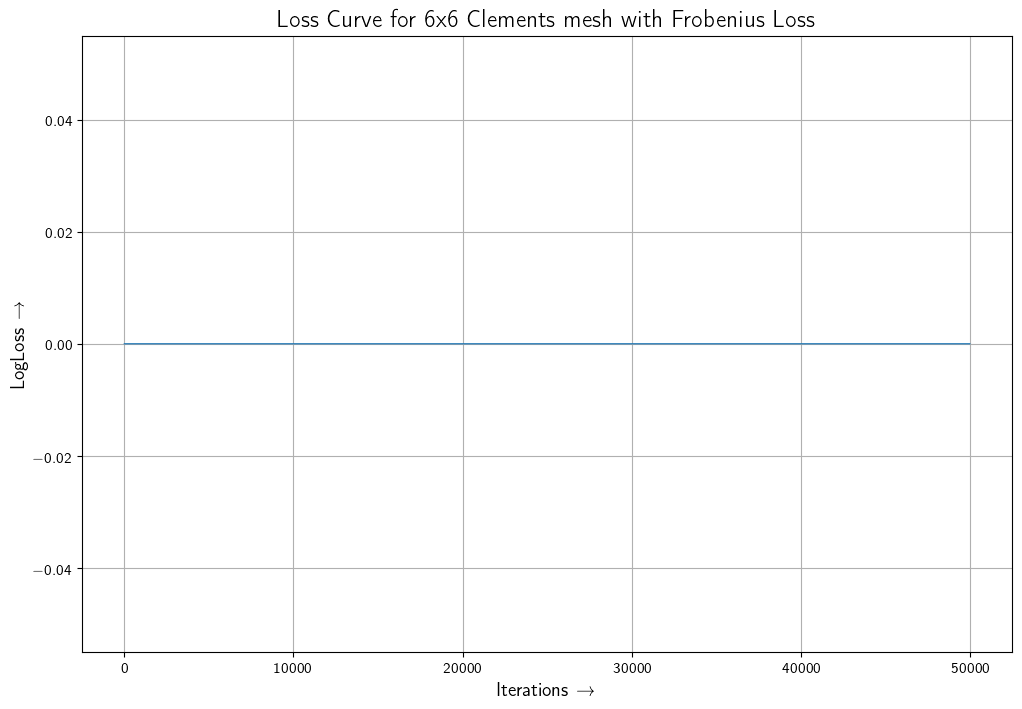

In [28]:
plot_loss_curve(50000, losses6, r'6x6 Clements mesh with Frobenius Loss')

In [29]:
compute_phase_deviation(U, best_layer6)

Actual theta errors: 
 [[ 11.6691195   12.77835076   7.90257753]
 [ 48.70022891  43.90865655 180.        ]
 [ 12.57158728  46.66063539  32.04429353]
 [ 10.02882311  35.48481349 180.        ]
 [  2.0938248   32.99711516  22.38087017]
 [ 68.24910117   8.08422129 180.        ]] 

Estimated theta errors: 
 [[ 11.66911694  12.77835845   7.90257839]
 [ 48.70023574  43.90864631 180.        ]
 [ 12.57157703  46.6606593   32.04429011]
 [ 10.02880945  35.48479642 180.        ]
 [  2.09382843  32.99711858  22.38086334]
 [ 68.24908751   8.08418202 180.        ]] 

Max theta error:  3.9273587727573316e-05
Min theta error:  8.537736462515939e-07
Mean theta error:  1.0885613989707822e-05 

Actual phi errors: 
 [[ 18.64788834  44.03623424  22.19478679]
 [  3.88008447  54.94090446 180.        ]
 [  5.21739666  31.59012693  45.09510139]
 [  9.20534391  14.5289291  180.        ]
 [ 30.55476587  25.9248214    9.38724892]
 [ 19.41035943  59.29596626 180.        ]] 

Estimated phi errors: 
 [[ 18.64791225  

In [18]:
# Actual theta errors
at = np.array([
    [11.6691195, 12.77835076, 7.90257753],
    [48.70022891, 43.90865655, 180.],
    [12.57158728, 46.66063539, 32.04429353],
    [10.02882311, 35.48481349, 180.],
    [2.0938248, 32.99711516, 22.38087017],
    [68.24910117, 8.08422129, 180.]
])

# Estimated theta errors
et = np.array([
    [11.66911694, 12.77835845, 7.90257839],
    [48.70023574, 43.90864631, 180.],
    [12.57157703, 46.6606593, 32.04429011],
    [10.02880945, 35.48479642, 180.],
    [2.09382843, 32.99711858, 22.38086334],
    [68.24908751, 8.08418202, 180.]
])

# Actual phi errors
ap = np.array([
    [18.64788834, 44.03623424, 22.19478679],
    [3.88008447, 54.94090446, 180.],
    [5.21739666, 31.59012693, 45.09510139],
    [9.20534391, 14.5289291, 180.],
    [30.55476587, 25.9248214, 9.38724892],
    [19.41035943, 59.29596626, 180.]
])

# Estimated phi errors
ep = np.array([
    [18.64791225, 44.03622399, 22.1947885],
    [3.88009088, 54.94091129, 180.],
    [5.21739112, 31.59011327, 45.09510139],
    [9.2057597, 14.52892569, 180.],
    [30.55435948, 25.92482482, 9.38723356],
    [19.41035431, 59.29595943, 180.]
])

# Actual gamma errors
ag = np.array([74.76558, 10.17161, 31.14296, 9.123834, 1.3578016, 20.890179])

# Estimated gamma errors
eg = np.array([74.76558, 10.171609, 31.142952, 9.1238575, 1.3578029, 20.890173])

A = RM(6)
B = RM(6)

PhaseInitializer(A, at, ap, ag)
PhaseInitializer(B, et, ep, eg)

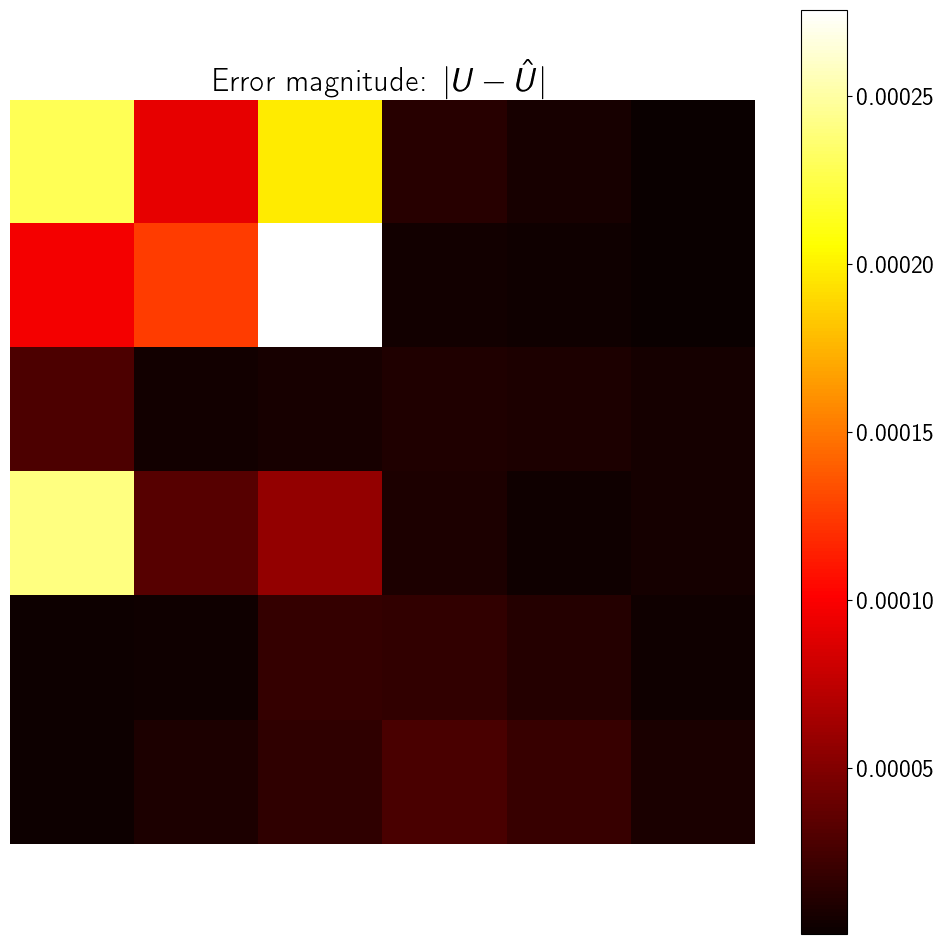

In [25]:
plot_error(A, B, r'$|U - \hat{U}|$')

In [30]:
SU = RM(6)
print(np.linalg.det(SU.matrix))
SU.gamma.assign(np.zeros((1, 6)))

(-0.27225673+0.9622253j)


<tf.Variable 'UnreadVariable' shape=(1, 6) dtype=float32, numpy=array([[0., 0., 0., 0., 0., 0.]], dtype=float32)>

In [35]:
mesh_phases, mesh_layers = SU.phases_and_layers

In [37]:
mesh_phases.input_phase_shift_layer

<tf.Tensor: shape=(1, 6), dtype=complex64, numpy=array([[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j]], dtype=complex64)>

In [31]:
np.linalg.det(SU.matrix)

(0.5166501-0.85619754j)

In [66]:
U = sp.stats.unitary_group.rvs(6)
d = np.linalg.det(U)
SU = U / d**(1/6)
np.linalg.det(SU)

(0.9999999999999994-1.6653345369377336e-16j)

In [70]:
t, p, g = clements_decomposition_working(SU)
l = RM(6)
PhaseInitializer(l, t, p, g)
print(SU,'\n', l.matrix)

[[-0.56671982-0.21057632j -0.10208652-0.12365989j  0.2673608 +0.56683201j
   0.13707097-0.19981011j -0.06485723+0.13972488j -0.34753856+0.11299297j]
 [-0.00477241+0.02280439j  0.03190687+0.50323904j  0.12594365-0.099987j
   0.67126629+0.42004099j  0.0974044 +0.24610738j -0.13941587+0.05295554j]
 [-0.08628793+0.2091189j   0.12915967+0.00734149j -0.1312715 +0.09892122j
  -0.06196519-0.15260397j -0.12505652+0.79357917j  0.32310506-0.3579642j ]
 [ 0.28806029-0.39379116j -0.2899599 -0.27845766j  0.43259644+0.09096777j
   0.24868958-0.02435317j  0.15885561+0.07338646j  0.55738833+0.03431533j]
 [-0.30067265+0.29310034j -0.04922855-0.6992779j  -0.08932594-0.27657114j
   0.37771843+0.24842615j -0.03152825-0.07853555j -0.0247485 -0.18879427j]
 [-0.02298829+0.40972746j  0.10631562+0.19736115j  0.11157272+0.51186799j
   0.13519203+0.04498565j -0.02727265-0.4714665j   0.32126775-0.40043125j]] 
 [[-0.5667198 -0.21057628j -0.10208651-0.12365991j  0.26736087+0.5668322j
   0.13707098-0.19981018j -0.064

In [73]:
l.phases.input_phase_shift_layer

array([[-0.95099956+0.3091923j ,  0.9348337 -0.35508588j,
         0.7163868 -0.69770336j, -0.96383077+0.2665151j ,
         0.99914515+0.04134005j,  0.7643581 -0.644792j  ]],
      dtype=complex64)

In [72]:
print(np.degrees(g))

[161.98943673 339.20128534 315.75697214 164.54299682   2.36928532
 319.84992596]


## Simulation 7

In [26]:
l7 = SVD(6, mesh_dict={"name" : "rm"})
NormalPhaseInitializer(l7.u, 0.1)
NormalPhaseInitializer(l7.v, 0.1)


(array([[0.4045325 , 0.82483705, 0.1632287 ],
        [0.77983439, 0.57037685, 0.        ],
        [1.9102165 , 0.90019325, 0.53791124],
        [0.79441816, 1.16861584, 0.        ],
        [0.06585408, 0.30660109, 0.50028291],
        [0.30927956, 0.09120861, 0.        ]]),
 array([[0.7631763 , 1.11360281, 0.17234466],
        [0.03336203, 0.44148204, 0.        ],
        [1.164398  , 0.03476754, 0.43195176],
        [0.14984803, 0.27973026, 0.        ],
        [0.20637086, 0.37818477, 0.04276789],
        [0.19720106, 0.0980555 , 0.        ]]),
 array([[0.23844011, 0.82242   , 0.39458752, 0.69365565, 0.80884541,
         0.25849254]]))

# Particle Swarm Optimization

In [71]:
def objective_function(params, target_matrix, N, layer):    
    n_particles = params.shape[0]
    losses = np.zeros(n_particles)

    for i in range(n_particles):
        A = compute_complex_matrix(params[i], N, layer)

        # Calculate the Frobenius norm (or another suitable norm)
        losses[i] = np.mean(np.abs(target_matrix - A)**2) / 2
    
    return losses

def compute_complex_matrix(params, N, layer):
    M = (N * (N-1)) // 2
    t, p, g = params[:M], params[M:2*M], params[2*M:]
    m = layer.phases.mask.astype(bool)
    theta, phi, _ = layer.phases.params
    np.putmask(theta, m, t)
    np.putmask(phi, m, p)
    
    PhaseInitializer(layer, theta, phi, g)

    return layer.matrix
    
def optimize(N, target_matrix, layer, n_particles=50, iters=1000, c1 = 0.5, c2 = 0.3, w = 0.9, bound_factor=0.5):
    # Dimension of each particle: N^2 
    dimensions = N**2
    M = (N*(N-1)) // 2
    
    # Bounds for the particles: different for theta and phi
    ul = np.zeros(dimensions)
    ul[:M] = np.pi * bound_factor
    ul[M:] = 2 * np.pi * bound_factor
    bounds = (np.zeros(dimensions), ul)
    
    # Create a PSO optimizer instance
    options = {'c1': c1, 'c2': c2, 'w': w}
    optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=dimensions, options=options, bounds=bounds)
    
    # Run the optimizer
    cost, pos = optimizer.optimize(objective_function, iters=iters, N=N, target_matrix=target_matrix, layer=layer)
    return cost, pos

In [74]:
U = RM(6)
phase_errors = NormalPhaseInitializer(U, 0.05)
target_matrix = U.matrix
phase_errors

(array([[1.01371871, 0.4898125 , 0.3432925 ],
        [0.43276222, 0.32232019, 0.        ],
        [0.05492197, 0.07458149, 0.12256829],
        [0.62216611, 0.27153574, 0.        ],
        [0.13967287, 0.01163517, 0.22710154],
        [0.30418661, 0.24986139, 0.        ]]),
 array([[0.40134243, 0.4527498 , 0.05703298],
        [0.40670055, 0.14669056, 0.        ],
        [0.18171497, 0.51792394, 0.11197251],
        [0.09663138, 0.32378765, 0.        ],
        [0.06347615, 0.0967555 , 0.32605226],
        [0.0164115 , 0.04283527, 0.        ]]),
 array([[0.44493558, 0.29546107, 0.24637368, 0.40239655, 0.2483387 ,
         0.28026426]]))

In [76]:
layer = RM(6)
cost, pos = optimize(6, target_matrix, layer, 1000, 100, bound_factor=0.3)
phase_errors, pos

2024-06-20 22:45:03,210 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|100/100, best_cost=0.0195
2024-06-20 22:58:27,369 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.019452562555670738, best pos: [0.64913914 0.43992712 0.41268118 0.63503969 0.41522301 0.29390458
 0.59599114 0.10663895 0.43954227 0.18393575 0.23236494 0.5005247
 0.23645025 0.48744837 0.18109037 0.35888326 0.14981073 1.3564367
 0.58136753 1.42904999 1.49821054 0.4869195  1.39159985 0.18140863
 1.12729413 0.59105432 1.17768331 1.40565905 0.02068932 0.42863515
 0.45112189 0.42690948 0.31921364 0.4856373  0.19084406 0.89140204]


((array([[1.01371871, 0.4898125 , 0.3432925 ],
         [0.43276222, 0.32232019, 0.        ],
         [0.05492197, 0.07458149, 0.12256829],
         [0.62216611, 0.27153574, 0.        ],
         [0.13967287, 0.01163517, 0.22710154],
         [0.30418661, 0.24986139, 0.        ]]),
  array([[0.40134243, 0.4527498 , 0.05703298],
         [0.40670055, 0.14669056, 0.        ],
         [0.18171497, 0.51792394, 0.11197251],
         [0.09663138, 0.32378765, 0.        ],
         [0.06347615, 0.0967555 , 0.32605226],
         [0.0164115 , 0.04283527, 0.        ]]),
  array([[0.44493558, 0.29546107, 0.24637368, 0.40239655, 0.2483387 ,
          0.28026426]])),
 array([0.64913914, 0.43992712, 0.41268118, 0.63503969, 0.41522301,
        0.29390458, 0.59599114, 0.10663895, 0.43954227, 0.18393575,
        0.23236494, 0.5005247 , 0.23645025, 0.48744837, 0.18109037,
        0.35888326, 0.14981073, 1.3564367 , 0.58136753, 1.42904999,
        1.49821054, 0.4869195 , 1.39159985, 0.18140863, 1.127294

best_cost = 0.118 @ n_particles = 400 and iters=1000

In [ ]:
target_matrix, compute_complex_matrix(pos, 6, layer)

In [55]:
U = RM(6)
phase_errors = NormalPhaseInitializer(U, 0.05)
target_matrix = U.matrix
phase_errors

(array([[0.19980734, 0.29162345, 0.28440621],
        [0.35268151, 0.06337189, 0.        ],
        [0.14564035, 0.38285323, 0.47068885],
        [0.06565121, 0.29946501, 0.        ],
        [0.3899872 , 0.30836938, 0.46717056],
        [0.7062159 , 0.04289093, 0.        ]]),
 array([[0.10119314, 0.00771319, 0.20507861],
        [0.18415229, 0.15194102, 0.        ],
        [0.2831282 , 0.381628  , 0.16286547],
        [0.19837727, 1.03201493, 0.        ],
        [0.02027195, 0.08984006, 0.23575439],
        [0.31717851, 0.05840642, 0.        ]]),
 array([[0.51546081, 0.53037693, 0.05705426, 0.16694048, 0.0572837 ,
         0.13017895]]))

In [56]:
layer = RM(6)
cost2, pos2 = optimize(6, target_matrix, layer, 10**5, 100, 0.2)
phase_errors, pos2

2024-06-20 01:04:41,170 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|          |0/100


### Multicore PNN (Work in progress)